In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("../data/raw/cybersecurity.csv")

In [3]:
df.shape

(10000, 13)

In [4]:
df.head()

,timestamp,src_ip,dst_ip,src_port,dst_port,protocol,bytes_sent,bytes_received,user_agent,url,is_internal_traffic,label,attack_type
0,2025-10-01 00:12:54,188.176.27.165,253.240.113.218,56377,445,TCP,8029,17204,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://webmail.corp/login?id=385071,False,0,benign
1,2025-10-01 00:23:43,68.59.26.43,212.75.38.111,51165,1433,TCP,676368,2643374,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://portal.example.org/owa/auth/logon.aspx...,False,0,benign
2,2025-10-01 00:25:46,119.204.243.78,90.28.90.234,14948,1433,TCP,316502,38571,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,NaN,False,0,benign
3,2025-10-01 00:27:21,122.119.194.175,175.140.78.230,36097,443,TCP,70933,21935,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://webmail.corp/phpmyadmin?id=114701,False,0,benign
4,2025-10-01 00:40:09,181.199.242.68,55.99.177.69,445,21255,TCP,12721,9939,Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...,https://portal.example.org/config.php?id=345569,False,0,benign


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   timestamp            10000 non-null  str  
 1   src_ip               10000 non-null  str  
 2   dst_ip               10000 non-null  str  
 3   src_port             10000 non-null  int64
 4   dst_port             10000 non-null  int64
 5   protocol             10000 non-null  str  
 6   bytes_sent           10000 non-null  int64
 7   bytes_received       10000 non-null  int64
 8   user_agent           10000 non-null  str  
 9   url                  6768 non-null   str  
 10  is_internal_traffic  10000 non-null  bool 
 11  label                10000 non-null  int64
 12  attack_type          10000 non-null  str  
dtypes: bool(1), int64(5), str(7)
memory usage: 947.4 KB


In [6]:
df["label"].value_counts()

label
0    9600
1     400
Name: count, dtype: int64

In [7]:
df["attack_type"].value_counts()

attack_type
benign                 9600
brute-force             108
port-scan                81
sql-injection            64
xss                      34
credential-stuffing      28
ddos                     27
command-injection        26
exploit-attempt          22
c2                       10
Name: count, dtype: int64

In [8]:
df["protocol"].value_counts()

protocol
TCP     7765
UDP     1910
ICMP     325
Name: count, dtype: int64

In [9]:
df.isnull().sum()

timestamp                 0
src_ip                    0
dst_ip                    0
src_port                  0
dst_port                  0
protocol                  0
bytes_sent                0
bytes_received            0
user_agent                0
url                    3232
is_internal_traffic       0
label                     0
attack_type               0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.describe()

,src_port,dst_port,bytes_sent,bytes_received,label
count,10000.000000,10000.000000,1.000000e+04,1.000000e+04,10000.000000
mean,27052.223700,2027.280500,1.412572e+05,2.620883e+05,0.040000
std,20978.783832,6769.141395,2.128140e+06,3.767695e+06,0.195969
min,21.000000,5.000000,1.700000e+01,3.000000e+00,0.000000
25%,6092.250000,25.000000,7.148250e+03,1.096075e+04,0.000000
50%,25431.500000,443.000000,2.181550e+04,3.747300e+04,0.000000
75%,45215.750000,1433.000000,6.509525e+04,1.213795e+05,0.000000
max,65524.000000,65491.000000,1.391704e+08,2.914830e+08,1.000000


In [12]:
df["timestamp"].min(), df["timestamp"].max()

('2025-10-01 00:12:54', '2025-12-29 23:26:12')

In [13]:
df["timestamp"].str[:10].value_counts().sort_index()

timestamp
2025-10-01    104
2025-10-02     92
2025-10-03     85
2025-10-04    111
2025-10-05    112
             ... 
2025-12-25    109
2025-12-26     99
2025-12-27     95
2025-12-28     99
2025-12-29    110
Name: count, Length: 90, dtype: int64

In [14]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

In [15]:
print(df["timestamp"])

0      2025-10-01 00:12:54
1      2025-10-01 00:23:43
2      2025-10-01 00:25:46
3      2025-10-01 00:27:21
4      2025-10-01 00:40:09
               ...        
9995   2025-12-29 22:56:36
9996   2025-12-29 23:03:05
9997   2025-12-29 23:11:46
9998   2025-12-29 23:20:46
9999   2025-12-29 23:26:12
Name: timestamp, Length: 10000, dtype: datetime64[us]


In [16]:
df["timestamp"].dt.hour.value_counts().sort_index()

timestamp
0     422
1     454
2     437
3     427
4     408
5     392
6     442
7     408
8     443
9     379
10    419
11    394
12    426
13    410
14    429
15    424
16    387
17    428
18    425
19    406
20    421
21    421
22    405
23    393
Name: count, dtype: int64

In [17]:
df[df["label"] == 1]["timestamp"].dt.hour.value_counts().sort_index()

timestamp
0     17
1     22
2     17
3     15
4     11
5     15
6     20
7     12
8     15
9     19
10    19
11    14
12    16
13    25
14    22
15    18
16    16
17    18
18    10
19    15
20    17
21    12
22    18
23    17
Name: count, dtype: int64

In [18]:
pd.crosstab(df["attack_type"], df["protocol"])

protocol,ICMP,TCP,UDP
attack_type,,,
benign,307,7451,1842
brute-force,3,85,20
c2,1,7,2
command-injection,0,23,3
credential-stuffing,0,23,5
ddos,3,17,7
exploit-attempt,0,18,4
port-scan,2,63,16
sql-injection,8,49,7


In [19]:
df["dst_port"].value_counts().head(15)

dst_port
80       1013
443      1009
1433      965
3306      965
22        960
25        947
21        938
53        934
3389      919
445       905
368         2
628         2
145         2
758         2
18283       2
Name: count, dtype: int64

In [20]:
df[df["label"] == 1]["dst_port"].value_counts().head(15)

dst_port
80      62
443     53
22      42
3389    38
53      24
25      23
445     19
1433    19
21      18
3306    15
368      2
628      2
145      2
758      2
231      2
Name: count, dtype: int64

In [21]:
pd.crosstab(df["is_internal_traffic"], df["label"])

label,0,1
is_internal_traffic,,
False,8126,340
True,1474,60


In [22]:
df.groupby("label")[["bytes_sent", "bytes_received"]].mean()

,bytes_sent,bytes_received
label,,
0,7.917183e+04,1.677655e+05
1,1.631307e+06,2.525835e+06


In [23]:
df[["bytes_sent", "bytes_received"]].corr()

,bytes_sent,bytes_received
bytes_sent,1.000000,0.876734
bytes_received,0.876734,1.000000


In [24]:
df[["src_port", "dst_port"]].corr()

,src_port,dst_port
src_port,1.000000,-0.012776
dst_port,-0.012776,1.000000


In [25]:
df_processed = df.copy()

In [26]:
# Feature Engineering.

In [27]:
df_processed["hour"] = df_processed["timestamp"].dt.hour

In [28]:
print(df_processed["hour"])

0        0
1        0
2        0
3        0
4        0
        ..
9995    22
9996    23
9997    23
9998    23
9999    23
Name: hour, Length: 10000, dtype: int32


In [29]:
df_processed["day_of_week"] = df_processed["timestamp"].dt.dayofweek

In [30]:
print(df_processed["day_of_week"])

0       2
1       2
2       2
3       2
4       2
       ..
9995    0
9996    0
9997    0
9998    0
9999    0
Name: day_of_week, Length: 10000, dtype: int32


In [31]:
df_processed["total_bytes"] = (
    df_processed["bytes_sent"] + df_processed["bytes_received"]
)

In [32]:
print(df_processed["total_bytes"])

0         25233
1       3319742
2        355073
3         92868
4         22660
         ...   
9995       1454
9996      27267
9997       8888
9998       9566
9999     778166
Name: total_bytes, Length: 10000, dtype: int64


In [33]:
df_processed["bytes_ratio"] = (
    df_processed["bytes_sent"] / (df_processed["bytes_received"] + 1)
)

In [34]:
df_processed["traffic_imbalance"] = (
    (df_processed["bytes_sent"] - df_processed["bytes_received"])
    / (df_processed["total_bytes"] + 1)
)

In [35]:
df_processed["protocol_code"] = df_processed["protocol"].map({
    "TCP": 0,
    "UDP": 1,
    "ICMP": 2
})

In [36]:
df_processed["internal_code"] = df_processed["is_internal_traffic"].astype(int)

In [37]:
common_ports = [21, 22, 25, 53, 80, 443, 445, 1433, 3306, 3389]

df_processed["common_dst_port"] = (
    df_processed["dst_port"].isin(common_ports).astype(int)
)

In [38]:
df_processed.columns

Index(['timestamp', 'src_ip', 'dst_ip', 'src_port', 'dst_port', 'protocol',
       'bytes_sent', 'bytes_received', 'user_agent', 'url',
       'is_internal_traffic', 'label', 'attack_type', 'hour', 'day_of_week',
       'total_bytes', 'bytes_ratio', 'traffic_imbalance', 'protocol_code',
       'internal_code', 'common_dst_port'],
      dtype='str')

In [39]:
df_processed[
    [
        "hour",
        "day_of_week",
        "total_bytes",
        "bytes_ratio",
        "traffic_imbalance",
        "protocol_code",
        "internal_code",
        "common_dst_port"
    ]
].describe()

,hour,day_of_week,total_bytes,bytes_ratio,traffic_imbalance,protocol_code,internal_code,common_dst_port
count,10000.00000,10000.000000,1.000000e+04,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000
mean,11.40380,3.007500,4.033455e+05,0.982975,-0.233039,0.25600,0.153400,0.955500
std,6.93981,1.999511,5.725742e+06,1.481957,0.366081,0.50546,0.360391,0.206213
min,0.00000,0.000000,2.000000e+01,0.238114,-0.615358,0.00000,0.000000,0.000000
25%,5.00000,1.000000,2.063400e+04,0.313593,-0.522494,0.00000,0.000000,1.000000
50%,11.00000,3.000000,6.326900e+04,0.467179,-0.363160,0.00000,0.000000,1.000000
75%,17.00000,5.000000,1.919850e+05,0.922601,-0.040099,0.00000,0.000000,1.000000
max,23.00000,6.000000,4.306534e+08,12.461538,0.851519,2.00000,1.000000,1.000000


In [40]:
df_processed["url"].notna().sum()

np.int64(6768)

In [41]:
df_processed["url_length"] = df_processed["url"].fillna("").str.len()

In [42]:
df_processed["has_query_params"] = (
    df_processed["url"].fillna("").str.contains(r"\?", regex=True).astype(int)
)

In [43]:
sensitive_keywords = r"login|admin|phpmyadmin|config|auth"

df_processed["has_sensitive_keyword"] = (
    df_processed["url"]
    .fillna("")
    .str.lower()
    .str.contains(sensitive_keywords, regex=True)
    .astype(int)
)

In [44]:
df_processed["url_path_depth"] = (
    df_processed["url"]
    .fillna("")
    .str.split("/")
    .str.len()
)

In [45]:
df_processed["url_path_depth"].describe()

count    10000.000000
mean         3.277800
std          1.683244
min          1.000000
25%          1.000000
50%          4.000000
75%          4.000000
max          6.000000
Name: url_path_depth, dtype: float64

In [46]:
df_processed[
    [
        "url_length",
        "has_query_params",
        "has_sensitive_keyword",
        "url_path_depth"
    ]
].describe()

,url_length,has_query_params,has_sensitive_keyword,url_path_depth
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,29.056600,0.676800,0.292600,3.277800
std,20.549735,0.467722,0.454979,1.683244
min,0.000000,0.000000,0.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000
50%,39.000000,1.000000,0.000000,4.000000
75%,45.000000,1.000000,1.000000,4.000000
max,57.000000,1.000000,1.000000,6.000000


In [47]:
df_processed["is_browser"] = (
    df_processed["user_agent"]
    .fillna("")
    .str.contains(
        r"Mozilla|Chrome|Firefox|Safari|Edge",
        case=False,
        regex=True
    )
    .astype(int)
)

In [48]:
df_processed["is_browser"].value_counts()

is_browser
1    8033
0    1967
Name: count, dtype: int64

In [49]:
df_processed.columns.tolist()

['timestamp',
 'src_ip',
 'dst_ip',
 'src_port',
 'dst_port',
 'protocol',
 'bytes_sent',
 'bytes_received',
 'user_agent',
 'url',
 'is_internal_traffic',
 'label',
 'attack_type',
 'hour',
 'day_of_week',
 'total_bytes',
 'bytes_ratio',
 'traffic_imbalance',
 'protocol_code',
 'internal_code',
 'common_dst_port',
 'url_length',
 'has_query_params',
 'has_sensitive_keyword',
 'url_path_depth',
 'is_browser']

In [50]:
feature_columns = [
    "src_port",
    "dst_port",
    "bytes_sent",
    "bytes_received",
    "hour",
    "day_of_week",
    "total_bytes",
    "bytes_ratio",
    "traffic_imbalance",
    "protocol_code",
    "internal_code",
    "common_dst_port",
    "url_length",
    "has_query_params",
    "has_sensitive_keyword",
    "url_path_depth",
    "is_browser"
]

X = df_processed[feature_columns].copy()

In [51]:
X.shape

(10000, 17)

In [52]:
X.isnull().sum()

src_port                 0
dst_port                 0
bytes_sent               0
bytes_received           0
hour                     0
day_of_week              0
total_bytes              0
bytes_ratio              0
traffic_imbalance        0
protocol_code            0
internal_code            0
common_dst_port          0
url_length               0
has_query_params         0
has_sensitive_keyword    0
url_path_depth           0
is_browser               0
dtype: int64

In [53]:
# Feature Scaling.

In [54]:
from sklearn.preprocessing import StandardScaler

In [55]:
scaler = StandardScaler()

In [56]:
X_scaled = scaler.fit_transform(X)

In [57]:
X_scaled.shape

(10000, 17)

In [58]:
X_scaled[:5]

array([[ 1.39790003, -0.23376076, -0.06260628, -0.06499903, -1.64332602,
        -0.50389844, -0.06604059, -0.34841357, -0.35665311, -0.50649494,
        -0.42567049,  0.21580657,  0.33789959,  0.69104368,  1.55487459,
         0.42907392,  0.49483829],
       [ 1.14944614, -0.08779699,  0.25145789,  0.63205884, -1.64332602,
        -0.50389844,  0.50937368, -0.49066082, -0.98201206, -0.50649494,
        -0.42567049,  0.21580657,  1.3111968 ,  0.69104368,  1.55487459,
         1.61731517,  0.49483829],
       [-0.57700337, -0.08779699,  0.08235057, -0.05932764, -1.64332602,
        -0.50389844, -0.00843121,  4.87387408,  2.77487772, -0.50649494,
        -0.42567049,  0.21580657, -1.41403538, -1.44708652, -0.64313868,
        -1.35328796,  0.49483829],
       [ 0.43116077, -0.23405623, -0.03304659, -0.06374329, -1.64332602,
        -0.50389844, -0.05422756,  1.51878349,  2.07790039, -0.50649494,
        -0.42567049,  0.21580657,  0.58122389,  0.69104368,  1.55487459,
         0.42907392

In [59]:
X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=feature_columns
)

X_scaled_df.head()

,src_port,dst_port,bytes_sent,bytes_received,hour,day_of_week,total_bytes,bytes_ratio,traffic_imbalance,protocol_code,internal_code,common_dst_port,url_length,has_query_params,has_sensitive_keyword,url_path_depth,is_browser
0,1.397900,-0.233761,-0.062606,-0.064999,-1.643326,-0.503898,-0.066041,-0.348414,-0.356653,-0.506495,-0.42567,0.215807,0.337900,0.691044,1.554875,0.429074,0.494838
1,1.149446,-0.087797,0.251458,0.632059,-1.643326,-0.503898,0.509374,-0.490661,-0.982012,-0.506495,-0.42567,0.215807,1.311197,0.691044,1.554875,1.617315,0.494838
2,-0.577003,-0.087797,0.082351,-0.059328,-1.643326,-0.503898,-0.008431,4.873874,2.774878,-0.506495,-0.42567,0.215807,-1.414035,-1.447087,-0.643139,-1.353288,0.494838
3,0.431161,-0.234056,-0.033047,-0.063743,-1.643326,-0.503898,-0.054228,1.518783,2.077900,-0.506495,-0.42567,0.215807,0.581224,0.691044,1.554875,0.429074,0.494838
4,-1.268355,2.840638,-0.060401,-0.066927,-1.643326,-0.503898,-0.066490,0.200288,0.971978,-0.506495,-0.42567,-4.633779,0.873213,0.691044,1.554875,0.429074,0.494838


In [60]:
X_scaled_df.describe().loc[["mean", "std"]]

,src_port,dst_port,bytes_sent,bytes_received,hour,day_of_week,total_bytes,bytes_ratio,traffic_imbalance,protocol_code,internal_code,common_dst_port,url_length,has_query_params,has_sensitive_keyword,url_path_depth,is_browser
mean,5.364598e-17,-1.563194e-17,-2.131628e-18,-1.421085e-18,-6.963319e-17,2.131628e-17,4.263256e-18,5.115908e-17,-9.521273e-17,-2.096101e-17,7.815970e-18,-7.958079e-17,-2.486900e-18,9.912071e-17,1.065814e-18,2.877698e-17,-6.750156e-18
std,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00,1.000050e+00


In [61]:
correlation_matrix = X_scaled_df.corr()

correlation_matrix.round(2)

,src_port,dst_port,bytes_sent,bytes_received,hour,day_of_week,total_bytes,bytes_ratio,traffic_imbalance,protocol_code,internal_code,common_dst_port,url_length,has_query_params,has_sensitive_keyword,url_path_depth,is_browser
src_port,1.00,-0.01,0.00,0.00,-0.01,0.01,0.00,-0.01,-0.01,0.00,-0.00,0.01,-0.00,-0.01,0.00,-0.00,0.03
dst_port,-0.01,1.00,-0.00,0.00,0.00,0.02,-0.00,-0.01,-0.01,0.00,-0.01,-0.76,0.01,0.01,-0.01,0.01,-0.00
bytes_sent,0.00,-0.00,1.00,0.88,0.01,-0.00,0.95,0.01,0.01,0.01,-0.00,0.00,-0.01,-0.01,-0.01,-0.01,-0.01
bytes_received,0.00,0.00,0.88,1.00,-0.00,-0.01,0.98,-0.02,-0.03,-0.01,0.00,-0.01,-0.00,-0.00,0.00,-0.00,-0.02
hour,-0.01,0.00,0.01,-0.00,1.00,-0.01,0.00,0.01,0.00,0.03,-0.00,0.01,-0.01,-0.01,-0.00,-0.01,-0.00
day_of_week,0.01,0.02,-0.00,-0.01,-0.01,1.00,-0.00,0.01,0.00,-0.02,0.01,-0.02,0.01,0.01,0.00,0.01,-0.00
total_bytes,0.00,-0.00,0.95,0.98,0.00,-0.00,1.00,-0.01,-0.01,-0.00,-0.00,-0.00,-0.01,-0.00,-0.00,-0.00,-0.02
bytes_ratio,-0.01,-0.01,0.01,-0.02,0.01,0.01,-0.01,1.00,0.82,-0.02,0.00,0.00,0.00,0.00,-0.00,0.00,0.00
traffic_imbalance,-0.01,-0.01,0.01,-0.03,0.00,0.00,-0.01,0.82,1.00,-0.01,0.00,0.01,0.01,0.01,-0.00,0.01,0.00
protocol_code,0.00,0.00,0.01,-0.01,0.03,-0.02,-0.00,-0.02,-0.01,1.00,0.01,0.01,-0.03,-0.03,-0.01,-0.03,-0.02


In [62]:
clustering_features = [
    "src_port",
    "dst_port",
    "bytes_sent",
    "bytes_received",
    "hour",
    "day_of_week",
    "bytes_ratio",
    "protocol_code",
    "internal_code",
    "url_length",
    "has_sensitive_keyword",
    "is_browser"
]

X_clustering = df_processed[clustering_features].copy()

X_clustering.shape

(10000, 12)

In [63]:
from sklearn.preprocessing import StandardScaler

clustering_scaler = StandardScaler()

X_clustering_scaled = clustering_scaler.fit_transform(X_clustering)

X_clustering_scaled.shape

(10000, 12)

In [64]:
X_clustering_scaled.shape

(10000, 12)

In [65]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=1.5,
    min_samples=10
)

In [66]:
dbscan_labels = dbscan.fit_predict(X_clustering_scaled)

In [67]:
import numpy as np

unique_labels, counts = np.unique(dbscan_labels, return_counts=True)

list(zip(unique_labels, counts))

[(np.int64(-1), np.int64(793)),
 (np.int64(0), np.int64(1482)),
 (np.int64(1), np.int64(3556)),
 (np.int64(2), np.int64(64)),
 (np.int64(3), np.int64(365)),
 (np.int64(4), np.int64(299)),
 (np.int64(5), np.int64(816)),
 (np.int64(6), np.int64(91)),
 (np.int64(7), np.int64(238)),
 (np.int64(8), np.int64(86)),
 (np.int64(9), np.int64(72)),
 (np.int64(10), np.int64(110)),
 (np.int64(11), np.int64(343)),
 (np.int64(12), np.int64(366)),
 (np.int64(13), np.int64(54)),
 (np.int64(14), np.int64(465)),
 (np.int64(15), np.int64(348)),
 (np.int64(16), np.int64(70)),
 (np.int64(17), np.int64(120)),
 (np.int64(18), np.int64(79)),
 (np.int64(19), np.int64(70)),
 (np.int64(20), np.int64(41)),
 (np.int64(21), np.int64(55)),
 (np.int64(22), np.int64(17))]

In [68]:
df_processed["cluster"] = dbscan_labels

df_processed[["label", "attack_type", "cluster"]].head()

,label,attack_type,cluster
0,0,benign,0
1,0,benign,0
2,0,benign,-1
3,0,benign,0
4,0,benign,-1


In [69]:
cluster_attack_summary = (
    df_processed.groupby("cluster")["label"]
    .agg(
        total_records="count",
        attacks="sum"
    )
)

cluster_attack_summary["attack_percentage"] = (
    cluster_attack_summary["attacks"]
    / cluster_attack_summary["total_records"]
    * 100
)

cluster_attack_summary.sort_values(
    "attack_percentage",
    ascending=False
)

,total_records,attacks,attack_percentage
cluster,,,
22,17,2,11.764706
19,70,8,11.428571
14,465,41,8.817204
3,365,31,8.493151
16,70,5,7.142857
12,366,26,7.103825
10,110,7,6.363636
2,64,4,6.250000
13,54,3,5.555556


In [70]:
cluster_attack_types = pd.crosstab(
    df_processed["cluster"],
    df_processed["attack_type"]
)

cluster_attack_types

attack_type,benign,brute-force,c2,command-injection,credential-stuffing,ddos,exploit-attempt,port-scan,sql-injection,xss
cluster,,,,,,,,,,
-1,749,5,1,1,0,19,1,4,10,3
0,1433,18,2,1,2,2,4,13,4,3
1,3447,35,4,5,14,3,5,36,4,3
2,60,3,0,0,0,0,0,1,0,0
3,334,6,0,4,1,0,2,4,7,7
4,290,2,1,0,3,0,1,2,0,0
5,794,6,0,1,5,1,2,6,1,0
6,87,0,0,1,0,0,0,1,2,0
7,233,2,0,0,0,0,2,1,0,0


In [71]:
cluster_profile = (
    df_processed.groupby("cluster")[clustering_features]
    .mean()
)

cluster_profile

,src_port,dst_port,bytes_sent,bytes_received,hour,day_of_week,bytes_ratio,protocol_code,internal_code,url_length,has_sensitive_keyword,is_browser
cluster,,,,,,,,,,,,
-1,27077.517024,14416.104666,960343.576293,1.543299e+06,11.240858,3.119798,3.277639,0.562421,0.310214,29.568726,0.30517,0.679697
0,27734.967611,969.694332,73922.674764,1.581970e+05,11.414980,3.009447,0.785769,0.000000,0.000000,44.441296,1.00000,1.000000
1,27339.478628,984.943757,67866.987627,1.428994e+05,11.322272,2.993813,0.855872,0.000000,0.000000,22.977503,0.00000,1.000000
2,26541.765625,635.968750,45464.140625,9.403431e+04,9.718750,2.593750,0.614938,1.000000,1.000000,44.468750,1.00000,1.000000
3,26768.882192,927.649315,71732.117808,1.578821e+05,11.205479,2.715068,0.791279,0.000000,0.000000,0.000000,0.00000,0.000000
4,28079.635452,938.802676,61224.036789,1.365572e+05,11.327759,3.204013,0.701197,0.000000,1.000000,0.000000,0.00000,1.000000
5,27042.409314,874.609069,68110.384804,1.634581e+05,11.971814,3.007353,0.751623,1.000000,0.000000,21.558824,0.00000,1.000000
6,25276.648352,975.978022,78480.681319,1.670747e+05,11.879121,2.791209,0.606304,1.000000,0.000000,44.560440,1.00000,0.000000
7,26072.819328,864.184874,56236.533613,1.218522e+05,11.352941,3.046218,0.695424,0.000000,1.000000,44.411765,1.00000,1.000000


In [72]:
cluster_profile_zscore = (
    cluster_profile - X_clustering.mean()
) / X_clustering.std()

cluster_profile_zscore.round(2)

,src_port,dst_port,bytes_sent,bytes_received,hour,day_of_week,bytes_ratio,protocol_code,internal_code,url_length,has_sensitive_keyword,is_browser
cluster,,,,,,,,,,,,
-1,0.00,1.83,0.38,0.34,-0.02,0.06,1.55,0.61,0.44,0.02,0.03,-0.31
0,0.03,-0.16,-0.03,-0.03,0.00,0.00,-0.13,-0.51,-0.43,0.75,1.55,0.49
1,0.01,-0.15,-0.03,-0.03,-0.01,-0.01,-0.09,-0.51,-0.43,-0.30,-0.64,0.49
2,-0.02,-0.21,-0.05,-0.04,-0.24,-0.21,-0.25,1.47,2.35,0.75,1.55,0.49
3,-0.01,-0.16,-0.03,-0.03,-0.03,-0.15,-0.13,-0.51,-0.43,-1.41,-0.64,-2.02
4,0.05,-0.16,-0.04,-0.03,-0.01,0.10,-0.19,-0.51,2.35,-1.41,-0.64,0.49
5,-0.00,-0.17,-0.03,-0.03,0.08,-0.00,-0.16,1.47,-0.43,-0.36,-0.64,0.49
6,-0.08,-0.16,-0.03,-0.03,0.07,-0.11,-0.25,1.47,-0.43,0.75,1.55,-2.02
7,-0.05,-0.17,-0.04,-0.04,-0.01,0.02,-0.19,-0.51,2.35,0.75,1.55,0.49


In [73]:
from sklearn.metrics import silhouette_score

non_noise_mask = dbscan_labels != -1

silhouette = silhouette_score(
    X_clustering_scaled[non_noise_mask],
    dbscan_labels[non_noise_mask]
)

silhouette

0.19322245104895866

In [74]:
dbscan_2 = DBSCAN(
    eps=1.2,
    min_samples=10
)

dbscan_labels_2 = dbscan_2.fit_predict(X_clustering_scaled)

unique_labels_2, counts_2 = np.unique(
    dbscan_labels_2,
    return_counts=True
)

list(zip(unique_labels_2, counts_2))

[(np.int64(-1), np.int64(1306)),
 (np.int64(0), np.int64(1456)),
 (np.int64(1), np.int64(1554)),
 (np.int64(2), np.int64(1931)),
 (np.int64(3), np.int64(295)),
 (np.int64(4), np.int64(402)),
 (np.int64(5), np.int64(231)),
 (np.int64(6), np.int64(387)),
 (np.int64(7), np.int64(359)),
 (np.int64(8), np.int64(58)),
 (np.int64(9), np.int64(97)),
 (np.int64(10), np.int64(332)),
 (np.int64(11), np.int64(348)),
 (np.int64(12), np.int64(450)),
 (np.int64(13), np.int64(339)),
 (np.int64(14), np.int64(114)),
 (np.int64(15), np.int64(19)),
 (np.int64(16), np.int64(58)),
 (np.int64(17), np.int64(68)),
 (np.int64(18), np.int64(41)),
 (np.int64(19), np.int64(17)),
 (np.int64(20), np.int64(52)),
 (np.int64(21), np.int64(21)),
 (np.int64(22), np.int64(12)),
 (np.int64(23), np.int64(11)),
 (np.int64(24), np.int64(10)),
 (np.int64(25), np.int64(10)),
 (np.int64(26), np.int64(4)),
 (np.int64(27), np.int64(10)),
 (np.int64(28), np.int64(8))]

In [75]:
non_noise_mask_2 = dbscan_labels_2 != -1

silhouette_2 = silhouette_score(
    X_clustering_scaled[non_noise_mask_2],
    dbscan_labels_2[non_noise_mask_2]
)

silhouette_2

0.21889487024443896

In [76]:
dbscan_3 = DBSCAN(
    eps=1.3,
    min_samples=10
)

dbscan_labels_3 = dbscan_3.fit_predict(X_clustering_scaled)

unique_labels_3, counts_3 = np.unique(
    dbscan_labels_3,
    return_counts=True
)

list(zip(unique_labels_3, counts_3))

[(np.int64(-1), np.int64(1084)),
 (np.int64(0), np.int64(1466)),
 (np.int64(1), np.int64(1568)),
 (np.int64(2), np.int64(361)),
 (np.int64(3), np.int64(1936)),
 (np.int64(4), np.int64(297)),
 (np.int64(5), np.int64(415)),
 (np.int64(6), np.int64(88)),
 (np.int64(7), np.int64(234)),
 (np.int64(8), np.int64(29)),
 (np.int64(9), np.int64(389)),
 (np.int64(10), np.int64(80)),
 (np.int64(11), np.int64(61)),
 (np.int64(12), np.int64(106)),
 (np.int64(13), np.int64(337)),
 (np.int64(14), np.int64(351)),
 (np.int64(15), np.int64(453)),
 (np.int64(16), np.int64(343)),
 (np.int64(17), np.int64(14)),
 (np.int64(18), np.int64(115)),
 (np.int64(19), np.int64(28)),
 (np.int64(20), np.int64(71)),
 (np.int64(21), np.int64(65)),
 (np.int64(22), np.int64(40)),
 (np.int64(23), np.int64(31)),
 (np.int64(24), np.int64(8)),
 (np.int64(25), np.int64(21)),
 (np.int64(26), np.int64(9))]

In [77]:
non_noise_mask_3 = dbscan_labels_3 != -1

silhouette_3 = silhouette_score(
    X_clustering_scaled[non_noise_mask_3],
    dbscan_labels_3[non_noise_mask_3]
)

silhouette_3

0.2206172423600767

In [78]:
cluster_sizes_3 = (
    pd.Series(dbscan_labels_3)
    .value_counts()
    .sort_index()
)

cluster_sizes_3

-1     1084
 0     1466
 1     1568
 2      361
 3     1936
 4      297
 5      415
 6       88
 7      234
 8       29
 9      389
 10      80
 11      61
 12     106
 13     337
 14     351
 15     453
 16     343
 17      14
 18     115
 19      28
 20      71
 21      65
 22      40
 23      31
 24       8
 25      21
 26       9
Name: count, dtype: int64

In [79]:
cluster_attack_summary_3 = (
    pd.DataFrame({
        "cluster": dbscan_labels_3,
        "label": df_processed["label"].values
    })
    .groupby("cluster")["label"]
    .agg(
        total_records="count",
        attacks="sum"
    )
)

cluster_attack_summary_3["attack_percentage"] = (
    cluster_attack_summary_3["attacks"]
    / cluster_attack_summary_3["total_records"]
    * 100
)

cluster_attack_summary_3.sort_values(
    "attack_percentage",
    ascending=False
)

,total_records,attacks,attack_percentage
cluster,,,
8,29,4,13.793103
21,65,8,12.307692
23,31,3,9.677419
15,453,41,9.050773
2,361,31,8.587258
14,351,24,6.837607
12,106,6,5.660377
-1,1084,57,5.258303
22,40,2,5.000000


In [80]:
cluster_attack_types_3 = pd.crosstab(
    pd.Series(dbscan_labels_3, name="cluster"),
    df_processed["attack_type"]
)

cluster_attack_types_3

attack_type,benign,brute-force,c2,command-injection,credential-stuffing,ddos,exploit-attempt,port-scan,sql-injection,xss
cluster,,,,,,,,,,
-1,1027,8,2,2,0,19,1,5,16,4
0,1417,18,2,1,2,2,4,13,4,3
1,1513,17,2,3,6,2,1,20,2,2
2,330,6,0,4,1,0,2,4,7,7
3,1883,17,2,2,8,1,4,16,2,1
4,288,2,1,0,3,0,1,2,0,0
5,400,4,0,1,4,1,1,4,0,0
6,84,0,0,1,0,0,0,1,2,0
7,229,2,0,0,0,0,2,1,0,0


In [81]:
df_processed["cluster_3"] = dbscan_labels_3

cluster_profile_3 = (
    df_processed.groupby("cluster_3")[clustering_features]
    .mean()
)

cluster_profile_3

,src_port,dst_port,bytes_sent,bytes_received,hour,day_of_week,bytes_ratio,protocol_code,internal_code,url_length,has_sensitive_keyword,is_browser
cluster_3,,,,,,,,,,,,
-1,27612.827491,11001.411439,735995.280443,1.192772e+06,11.654059,3.111624,3.019280,0.602399,0.309963,29.479705,0.321956,0.667897
0,27741.376535,948.409277,72422.615962,1.571084e+05,11.418827,3.012960,0.745833,0.000000,0.000000,44.448840,1.000000,1.000000
1,27439.551020,926.627551,64970.077806,1.432381e+05,11.322066,2.954719,0.766584,0.000000,0.000000,0.000000,0.000000,1.000000
2,26765.174515,923.426593,72221.781163,1.595480e+05,11.149584,2.706371,0.756942,0.000000,0.000000,0.000000,0.000000,0.000000
3,27125.388946,993.494835,67637.154959,1.394239e+05,11.230888,3.010847,0.813263,0.000000,0.000000,41.721074,0.000000,1.000000
4,27978.181818,944.676768,59876.393939,1.370143e+05,11.326599,3.208754,0.682346,0.000000,1.000000,0.000000,0.000000,1.000000
5,28346.877108,853.913253,73575.190361,1.829412e+05,11.922892,3.045783,0.720355,1.000000,0.000000,41.498795,0.000000,1.000000
6,25027.181818,970.204545,80066.954545,1.699295e+05,11.965909,2.727273,0.591540,1.000000,0.000000,44.568182,1.000000,0.000000
7,26277.555556,858.525641,55741.286325,1.234803e+05,11.337607,3.047009,0.647355,0.000000,1.000000,44.465812,1.000000,1.000000


In [82]:
cluster_summary_3 = (
    df_processed.groupby("cluster_3")
    .agg(
        total_records=("label", "count"),
        attacks=("label", "sum"),
        attack_rate=("label", "mean")
    )
    .sort_values("attack_rate", ascending=False)
)

cluster_summary_3

,total_records,attacks,attack_rate
cluster_3,,,
8,29,4,0.137931
21,65,8,0.123077
23,31,3,0.096774
15,453,41,0.090508
2,361,31,0.085873
14,351,24,0.068376
12,106,6,0.056604
-1,1084,57,0.052583
22,40,2,0.050000


In [83]:
protocol_encoded = pd.get_dummies(
    df_processed["protocol"],
    prefix="protocol",
    dtype=int
)

protocol_encoded.head()

,protocol_ICMP,protocol_TCP,protocol_UDP
0,0,1,0
1,0,1,0
2,0,1,0
3,0,1,0
4,0,1,0


In [84]:
id="r4m2kx"
X_improved = pd.concat(
    [
        df_processed[
            [
                "src_port",
                "dst_port",
                "bytes_sent",
                "bytes_received",
                "hour",
                "day_of_week",
                "bytes_ratio",
                "internal_code",
                "url_length",
                "has_sensitive_keyword",
                "is_browser"
            ]
        ],
        protocol_encoded
    ],
    axis=1
)

X_improved.shape

(10000, 14)

In [85]:
from sklearn.preprocessing import StandardScaler

improved_scaler = StandardScaler()

X_improved_scaled = improved_scaler.fit_transform(X_improved)

X_improved_scaled.shape

(10000, 14)

In [86]:
from sklearn.cluster import DBSCAN

dbscan_improved = DBSCAN(
    eps=1.3,
    min_samples=10
)

improved_labels = dbscan_improved.fit_predict(X_improved_scaled)

pd.Series(improved_labels).value_counts().sort_index()

-1     1084
 0     1466
 1     1568
 2      361
 3     1936
 4      297
 5      415
 6       88
 7      234
 8       29
 9      389
 10      80
 11      61
 12     106
 13     337
 14     351
 15     453
 16     343
 17      14
 18     115
 19      28
 20      71
 21      65
 22      40
 23      31
 24       8
 25      21
 26       9
Name: count, dtype: int64

In [87]:
from sklearn.metrics import silhouette_score

non_noise_mask_improved = improved_labels != -1

silhouette_improved = silhouette_score(
    X_improved_scaled[non_noise_mask_improved],
    improved_labels[non_noise_mask_improved]
)

silhouette_improved

0.24973458905863702

In [88]:
df_processed["improved_cluster"] = improved_labels

df_processed[["improved_cluster", "label", "attack_type"]].head()

,improved_cluster,label,attack_type
0,0,0,benign
1,0,0,benign
2,-1,0,benign
3,0,0,benign
4,-1,0,benign


In [89]:
improved_cluster_summary = (
    df_processed.groupby("improved_cluster")
    .agg(
        total_records=("label", "count"),
        attacks=("label", "sum"),
        attack_rate=("label", "mean")
    )
    .sort_values("attack_rate", ascending=False)
)

improved_cluster_summary

,total_records,attacks,attack_rate
improved_cluster,,,
8,29,4,0.137931
21,65,8,0.123077
23,31,3,0.096774
15,453,41,0.090508
2,361,31,0.085873
14,351,24,0.068376
12,106,6,0.056604
-1,1084,57,0.052583
22,40,2,0.050000


In [90]:
improved_attack_types = pd.crosstab(
    df_processed["improved_cluster"],
    df_processed["attack_type"]
)

improved_attack_types

attack_type,benign,brute-force,c2,command-injection,credential-stuffing,ddos,exploit-attempt,port-scan,sql-injection,xss
improved_cluster,,,,,,,,,,
-1,1027,8,2,2,0,19,1,5,16,4
0,1417,18,2,1,2,2,4,13,4,3
1,1513,17,2,3,6,2,1,20,2,2
2,330,6,0,4,1,0,2,4,7,7
3,1883,17,2,2,8,1,4,16,2,1
4,288,2,1,0,3,0,1,2,0,0
5,400,4,0,1,4,1,1,4,0,0
6,84,0,0,1,0,0,0,1,2,0
7,229,2,0,0,0,0,2,1,0,0


In [91]:
attack_columns = [
    "brute-force",
    "c2",
    "command-injection",
    "credential-stuffing",
    "ddos",
    "exploit-attempt",
    "port-scan",
    "sql-injection",
    "xss"
]

cluster_attack_counts = improved_attack_types[attack_columns]

dominant_attack = cluster_attack_counts.idxmax(axis=1)
dominant_attack_count = cluster_attack_counts.max(axis=1)

dominant_attack_summary = pd.DataFrame({
    "dominant_attack": dominant_attack,
    "attack_count": dominant_attack_count
})

dominant_attack_summary

,dominant_attack,attack_count
improved_cluster,,
-1,ddos,19
0,brute-force,18
1,port-scan,20
2,sql-injection,7
3,brute-force,17
4,credential-stuffing,3
5,brute-force,4
6,sql-injection,2
7,brute-force,2


In [92]:
df_processed["month"] = df_processed["timestamp"].dt.to_period("M")

monthly_cluster_counts = pd.crosstab(
    df_processed["month"],
    df_processed["improved_cluster"]
)

monthly_cluster_counts

improved_cluster,-1,0,1,2,3,4,5,6,7,8,...,17,18,19,20,21,22,23,24,25,26
month,,,,,,,,,,,,,,,,,,,,,
2025-10,388,484,515,117,672,91,139,32,85,5,...,6,39,11,28,22,10,10,4,7,3
2025-11,360,486,542,122,652,110,146,24,70,13,...,4,43,7,17,25,17,12,3,10,4
2025-12,336,496,511,122,612,96,130,32,79,11,...,4,33,10,26,18,13,9,1,4,2


In [93]:
monthly_cluster_attacks = pd.crosstab(
    df_processed["month"],
    df_processed["improved_cluster"],
    values=df_processed["label"],
    aggfunc="sum"
).fillna(0)

monthly_cluster_attacks

improved_cluster,-1,0,1,2,3,4,5,6,7,8,...,17,18,19,20,21,22,23,24,25,26
month,,,,,,,,,,,,,,,,,,,,,
2025-10,24,10,20,7,17,3,5,2,1,0,...,0,1,0,1,3,1,2,0,0,0
2025-11,20,23,16,13,23,0,6,0,1,2,...,0,0,0,0,2,0,0,0,0,0
2025-12,13,16,19,11,13,6,4,2,3,2,...,0,2,1,0,3,1,1,0,0,0


In [94]:
monthly_attack_type = pd.crosstab(
    [
        df_processed["month"],
        df_processed["improved_cluster"]
    ],
    df_processed["attack_type"]
)

monthly_attack_type

attack_type               benign  brute-force  c2  command-injection  \
month   improved_cluster                                               
2025-10 -1                   364            1   2                  1   
         0                   474            5   1                  0   
         1                   495            5   0                  3   
         2                   110            1   0                  1   
         3                   655            4   1                  1   
...                          ...          ...  ..                ...   
2025-12  22                   12            0   0                  0   
         23                    8            0   0                  0   
         24                    1            0   0                  0   
         25                    4            0   0                  0   
         26                    2            0   0                  0   

attack_type               credential-stuffing  ddos  exploit-attempt  \
month   improved_cluster                                               
2025-10 -1                                  0     8                0   
         0                                  2     0                0   
         1                                  1     0                0   
         2                                  0     0                0   
         3                                  2     0                1   
...                                       ...   ...              ...   
2025-12  22                                 0     0                0   
         23                                 0     1                0   
         24                                 0     0                0   
         25                                 0     0                0   
         26                                 0     0                0   

attack_type               port-scan  sql-injection  xss  
month   improved_cluster                                 
2025-10 -1                        3              7    2  
         0                        0              2    0  
         1                        9              0    2  
         2                        1              2    2  
         3                        7              1    0  
...                             ...            ...  ...  
2025-12  22                       0              1    0  
         23                       0              0    0  
         24                       0              0    0  
         25                       0              0    0  
         26                       0              0    0  

[84 rows x 10 columns]

In [95]:
recurring_patterns = (
    monthly_attack_type
    .drop(columns="benign")
    .gt(0)
    .groupby(level=1)
    .sum()
)

recurring_patterns

attack_type,brute-force,c2,command-injection,credential-stuffing,ddos,exploit-attempt,port-scan,sql-injection,xss
improved_cluster,,,,,,,,,
-1,3,1,2,0,3,1,3,3,2
0,3,2,1,1,1,2,2,3,2
1,3,2,1,3,2,1,3,2,1
2,3,0,3,1,0,2,3,3,3
3,3,2,2,3,1,2,3,2,1
4,1,1,0,1,0,1,1,0,0
5,3,0,1,2,1,1,2,0,0
6,0,0,1,0,0,0,1,1,0
7,1,0,0,0,0,2,1,0,0


In [96]:
strong_recurring_patterns = (
    recurring_patterns[
        recurring_patterns.ge(3).any(axis=1)
    ]
)

strong_recurring_patterns

attack_type,brute-force,c2,command-injection,credential-stuffing,ddos,exploit-attempt,port-scan,sql-injection,xss
improved_cluster,,,,,,,,,
-1,3,1,2,0,3,1,3,3,2
0,3,2,1,1,1,2,2,3,2
1,3,2,1,3,2,1,3,2,1
2,3,0,3,1,0,2,3,3,3
3,3,2,2,3,1,2,3,2,1
5,3,0,1,2,1,1,2,0,0
14,2,0,3,0,0,1,0,3,2
15,3,0,2,3,0,1,1,3,3
16,2,0,0,0,0,2,3,0,1


In [97]:
cluster_attack_rate = (
    pd.crosstab(
        df_processed["improved_cluster"],
        df_processed["attack_type"],
        normalize="index"
    )
)

cluster_attack_rate = cluster_attack_rate.drop(columns="benign")

cluster_attack_rate.loc[
    strong_recurring_patterns.index
]

attack_type,brute-force,c2,command-injection,credential-stuffing,ddos,exploit-attempt,port-scan,sql-injection,xss
improved_cluster,,,,,,,,,
-1,0.007380,0.001845,0.001845,0.000000,0.017528,0.000923,0.004613,0.014760,0.003690
0,0.012278,0.001364,0.000682,0.001364,0.001364,0.002729,0.008868,0.002729,0.002046
1,0.010842,0.001276,0.001913,0.003827,0.001276,0.000638,0.012755,0.001276,0.001276
2,0.016620,0.000000,0.011080,0.002770,0.000000,0.005540,0.011080,0.019391,0.019391
3,0.008781,0.001033,0.001033,0.004132,0.000517,0.002066,0.008264,0.001033,0.000517
5,0.009639,0.000000,0.002410,0.009639,0.002410,0.002410,0.009639,0.000000,0.000000
14,0.011396,0.000000,0.019943,0.000000,0.000000,0.002849,0.000000,0.022792,0.011396
15,0.028698,0.000000,0.008830,0.006623,0.000000,0.002208,0.002208,0.028698,0.013245
16,0.011662,0.000000,0.000000,0.000000,0.000000,0.005831,0.008746,0.000000,0.002915


In [98]:
candidate_clusters = [1, 2, 14, 15, 16]

candidate_behavior = cluster_profile_3.loc[
    candidate_clusters
]

candidate_behavior

,src_port,dst_port,bytes_sent,bytes_received,hour,day_of_week,bytes_ratio,protocol_code,internal_code,url_length,has_sensitive_keyword,is_browser
cluster_3,,,,,,,,,,,,
1,27439.551020,926.627551,64970.077806,143238.128189,11.322066,2.954719,0.766584,0.0,0.0,0.000000,0.0,1.0
2,26765.174515,923.426593,72221.781163,159547.952909,11.149584,2.706371,0.756942,0.0,0.0,0.000000,0.0,0.0
14,26781.179487,943.284900,84244.142450,179774.820513,11.259259,3.102564,0.621997,0.0,0.0,44.717949,1.0,0.0
15,26171.233996,990.220751,73316.505519,141844.384106,11.258278,3.158940,0.739572,0.0,0.0,41.944812,0.0,0.0
16,27427.807580,821.568513,61094.492711,123162.580175,11.192420,3.020408,0.701251,1.0,0.0,44.880466,1.0,1.0


In [100]:
profile_data = pd.concat(
    [
        df_processed[
            [
                "improved_cluster",
                "src_port",
                "dst_port",
                "bytes_sent",
                "bytes_received",
                "hour",
                "day_of_week",
                "bytes_ratio",
                "internal_code",
                "url_length",
                "has_sensitive_keyword",
                "is_browser"
            ]
        ],
        protocol_encoded
    ],
    axis=1
)

improved_cluster_profile = (
    profile_data
    .groupby("improved_cluster")
    .mean()
)

improved_cluster_profile.loc[candidate_clusters]

,src_port,dst_port,bytes_sent,bytes_received,hour,day_of_week,bytes_ratio,internal_code,url_length,has_sensitive_keyword,is_browser,protocol_ICMP,protocol_TCP,protocol_UDP
improved_cluster,,,,,,,,,,,,,,
1,27439.551020,926.627551,64970.077806,143238.128189,11.322066,2.954719,0.766584,0.0,0.000000,0.0,1.0,0.0,1.0,0.0
2,26765.174515,923.426593,72221.781163,159547.952909,11.149584,2.706371,0.756942,0.0,0.000000,0.0,0.0,0.0,1.0,0.0
14,26781.179487,943.284900,84244.142450,179774.820513,11.259259,3.102564,0.621997,0.0,44.717949,1.0,0.0,0.0,1.0,0.0
15,26171.233996,990.220751,73316.505519,141844.384106,11.258278,3.158940,0.739572,0.0,41.944812,0.0,0.0,0.0,1.0,0.0
16,27427.807580,821.568513,61094.492711,123162.580175,11.192420,3.020408,0.701251,0.0,44.880466,1.0,1.0,0.0,0.0,1.0


In [101]:
overall_attack_rate = (
    df_processed["label"].mean()
)

candidate_attack_counts = pd.crosstab(
    df_processed["improved_cluster"],
    df_processed["attack_type"]
)

candidate_cluster_sizes = (
    df_processed["improved_cluster"]
    .value_counts()
)

candidate_attack_rate = (
    candidate_attack_counts
    .div(candidate_cluster_sizes, axis=0)
)

attack_totals = (
    df_processed["attack_type"]
    .value_counts()
)

overall_attack_type_rate = (
    attack_totals / len(df_processed)
)

candidate_attack_lift = (
    candidate_attack_rate
    .div(overall_attack_type_rate, axis=1)
)

candidate_attack_lift.loc[candidate_clusters]


attack_type,benign,brute-force,c2,command-injection,credential-stuffing,ddos,exploit-attempt,port-scan,sql-injection,xss
improved_cluster,,,,,,,,,,
1,1.005129,1.003874,1.27551,0.735871,1.366618,0.472411,0.289889,1.574704,0.199298,0.375150
2,0.952216,1.538935,0.00000,4.261666,0.989315,0.000000,2.518257,1.367942,3.029778,5.703112
14,0.970442,1.055186,0.00000,7.670392,0.000000,0.000000,1.295001,0.000000,3.561254,3.351768
15,0.947388,2.657183,0.00000,3.396162,2.365184,0.000000,1.003412,0.272532,4.483996,3.895598
16,1.011297,1.079797,0.00000,0.000000,0.000000,0.000000,2.650411,1.079797,0.000000,0.857486


In [102]:
attack_only_lift = candidate_attack_lift.drop(columns="benign")

strongest_associations = (
    attack_only_lift
    .stack()
    .reset_index()
)

strongest_associations.columns = [
    "cluster",
    "attack_type",
    "lift"
]

strongest_associations = (
    strongest_associations
    .sort_values("lift", ascending=False)
)

strongest_associations.head(15)

,cluster,attack_type,lift
206,21,xss,13.574661
100,10,c2,12.500000
220,23,ddos,11.947431
188,19,xss,10.504202
205,21,sql-injection,9.615385
81,8,brute-force,9.578544
214,22,sql-injection,7.812500
137,14,command-injection,7.670392
4,-1,ddos,6.491732
35,2,xss,5.703112


In [103]:
pattern_candidates = strongest_associations[
    (strongest_associations["lift"] >= 3)
].copy()

pattern_candidates

,cluster,attack_type,lift
206,21,xss,13.574661
100,10,c2,12.500000
220,23,ddos,11.947431
188,19,xss,10.504202
205,21,sql-injection,9.615385
81,8,brute-force,9.578544
214,22,sql-injection,7.812500
137,14,command-injection,7.670392
4,-1,ddos,6.491732
35,2,xss,5.703112


In [104]:
pattern_evidence = pattern_candidates.copy()

pattern_evidence["attack_count"] = [
    candidate_attack_counts.loc[
        row["cluster"], row["attack_type"]
    ]
    for _, row in pattern_evidence.iterrows()
]

pattern_evidence["cluster_size"] = [
    candidate_cluster_sizes.loc[row["cluster"]]
    for _, row in pattern_evidence.iterrows()
]

pattern_evidence["months_present"] = [
    recurring_patterns.loc[
        row["cluster"], row["attack_type"]
    ]
    for _, row in pattern_evidence.iterrows()
]

pattern_evidence

,cluster,attack_type,lift,attack_count,cluster_size,months_present
206,21,xss,13.574661,3,65,2
100,10,c2,12.500000,1,80,1
220,23,ddos,11.947431,1,31,1
188,19,xss,10.504202,1,28,1
205,21,sql-injection,9.615385,4,65,2
81,8,brute-force,9.578544,3,29,2
214,22,sql-injection,7.812500,2,40,2
137,14,command-injection,7.670392,7,351,3
4,-1,ddos,6.491732,19,1084,3
35,2,xss,5.703112,7,361,3


In [105]:
recurring_pattern_candidates = pattern_evidence[
    (pattern_evidence["attack_count"] >= 3) &
    (pattern_evidence["months_present"] >= 2) &
    (pattern_evidence["lift"] >= 3) &
    (pattern_evidence["cluster"] != -1)
].copy()

recurring_pattern_candidates = recurring_pattern_candidates.sort_values(
    ["months_present", "attack_count", "lift"],
    ascending=[False, False, False]
)

recurring_pattern_candidates

,cluster,attack_type,lift,attack_count,cluster_size,months_present
151,15,sql-injection,4.483996,13,453,3
142,14,sql-injection,3.561254,8,351,3
137,14,command-injection,7.670392,7,351,3
35,2,xss,5.703112,7,361,3
34,2,sql-injection,3.029778,7,361,3
152,15,xss,3.895598,6,453,3
29,2,command-injection,4.261666,4,361,3
205,21,sql-injection,9.615385,4,65,2
57,5,credential-stuffing,3.442341,4,415,2
146,15,command-injection,3.396162,4,453,2


In [106]:
pattern_clusters = recurring_pattern_candidates["cluster"].unique()

pattern_behavior = improved_cluster_profile.loc[
    pattern_clusters
].copy()

pattern_behavior

,src_port,dst_port,bytes_sent,bytes_received,hour,day_of_week,bytes_ratio,internal_code,url_length,has_sensitive_keyword,is_browser,protocol_ICMP,protocol_TCP,protocol_UDP
improved_cluster,,,,,,,,,,,,,,
15,26171.233996,990.220751,73316.505519,141844.384106,11.258278,3.158940,0.739572,0.0,41.944812,0.0,0.0,0.0,1.0,0.0
14,26781.179487,943.284900,84244.142450,179774.820513,11.259259,3.102564,0.621997,0.0,44.717949,1.0,0.0,0.0,1.0,0.0
2,26765.174515,923.426593,72221.781163,159547.952909,11.149584,2.706371,0.756942,0.0,0.000000,0.0,0.0,0.0,1.0,0.0
21,19579.830769,780.723077,84942.384615,183043.507692,12.169231,3.846154,0.592625,1.0,41.830769,0.0,0.0,0.0,1.0,0.0
5,28346.877108,853.913253,73575.190361,182941.154217,11.922892,3.045783,0.720355,0.0,41.498795,0.0,1.0,0.0,0.0,1.0
8,9647.206897,653.689655,40550.310345,86944.724138,7.206897,2.206897,0.572065,1.0,43.689655,1.0,1.0,0.0,0.0,1.0


In [108]:
pattern_behavior.reset_index().columns

Index(['improved_cluster', 'src_port', 'dst_port', 'bytes_sent',
       'bytes_received', 'hour', 'day_of_week', 'bytes_ratio', 'internal_code',
       'url_length', 'has_sensitive_keyword', 'is_browser', 'protocol_ICMP',
       'protocol_TCP', 'protocol_UDP'],
      dtype='str')

In [109]:
pattern_summary = recurring_pattern_candidates.merge(
    pattern_behavior.reset_index(),
    left_on="cluster",
    right_on="improved_cluster",
    how="left"
)

pattern_summary

,cluster,attack_type,lift,attack_count,cluster_size,months_present,improved_cluster,src_port,dst_port,bytes_sent,...,hour,day_of_week,bytes_ratio,internal_code,url_length,has_sensitive_keyword,is_browser,protocol_ICMP,protocol_TCP,protocol_UDP
0,15,sql-injection,4.483996,13,453,3,15,26171.233996,990.220751,73316.505519,...,11.258278,3.158940,0.739572,0.0,41.944812,0.0,0.0,0.0,1.0,0.0
1,14,sql-injection,3.561254,8,351,3,14,26781.179487,943.284900,84244.142450,...,11.259259,3.102564,0.621997,0.0,44.717949,1.0,0.0,0.0,1.0,0.0
2,14,command-injection,7.670392,7,351,3,14,26781.179487,943.284900,84244.142450,...,11.259259,3.102564,0.621997,0.0,44.717949,1.0,0.0,0.0,1.0,0.0
3,2,xss,5.703112,7,361,3,2,26765.174515,923.426593,72221.781163,...,11.149584,2.706371,0.756942,0.0,0.000000,0.0,0.0,0.0,1.0,0.0
4,2,sql-injection,3.029778,7,361,3,2,26765.174515,923.426593,72221.781163,...,11.149584,2.706371,0.756942,0.0,0.000000,0.0,0.0,0.0,1.0,0.0
5,15,xss,3.895598,6,453,3,15,26171.233996,990.220751,73316.505519,...,11.258278,3.158940,0.739572,0.0,41.944812,0.0,0.0,0.0,1.0,0.0
6,2,command-injection,4.261666,4,361,3,2,26765.174515,923.426593,72221.781163,...,11.149584,2.706371,0.756942,0.0,0.000000,0.0,0.0,0.0,1.0,0.0
7,21,sql-injection,9.615385,4,65,2,21,19579.830769,780.723077,84942.384615,...,12.169231,3.846154,0.592625,1.0,41.830769,0.0,0.0,0.0,1.0,0.0
8,5,credential-stuffing,3.442341,4,415,2,5,28346.877108,853.913253,73575.190361,...,11.922892,3.045783,0.720355,0.0,41.498795,0.0,1.0,0.0,0.0,1.0
9,15,command-injection,3.396162,4,453,2,15,26171.233996,990.220751,73316.505519,...,11.258278,3.158940,0.739572,0.0,41.944812,0.0,0.0,0.0,1.0,0.0


In [110]:
from sklearn.metrics.pairwise import cosine_similarity

candidate_behavior = pattern_behavior.loc[
    pattern_clusters
].copy()

candidate_similarity = pd.DataFrame(
    cosine_similarity(candidate_behavior),
    index=candidate_behavior.index,
    columns=candidate_behavior.index
)

candidate_similarity

improved_cluster,15,14,2,21,5,8
improved_cluster,,,,,,
15,1.000000,0.998859,0.998623,0.996948,0.995430,0.997252
14,0.998859,1.000000,0.999761,0.999295,0.998433,0.999423
2,0.998623,0.999761,1.000000,0.998447,0.999069,0.998613
21,0.996948,0.999295,0.998447,1.000000,0.997603,0.999988
5,0.995430,0.998433,0.999069,0.997603,1.000000,0.997655
8,0.997252,0.999423,0.998613,0.999988,0.997655,1.000000


In [111]:
selected_clusters = [2, 5, 8, 14, 15, 21]

monthly_pattern_attacks = pd.crosstab(
    [
        df_processed["month"],
        df_processed["improved_cluster"]
    ],
    df_processed["attack_type"]
)

monthly_pattern_attacks.loc[
    monthly_pattern_attacks.index.get_level_values("improved_cluster").isin(
        selected_clusters
    )
]

attack_type               benign  brute-force  c2  command-injection  \
month   improved_cluster                                               
2025-10 2                    110            1   0                  1   
        5                    134            1   0                  0   
        8                      5            0   0                  0   
        14                   111            3   0                  2   
        15                   133            4   0                  1   
        21                    19            1   0                  0   
2025-11 2                    109            4   0                  2   
        5                    140            1   0                  1   
        8                     11            2   0                  0   
        14                   108            0   0                  2   
        15                   145            4   0                  0   
        21                    23            0   0                  0   
2025-12 2                    111            1   0                  1   
        5                    126            2   0                  0   
        8                      9            1   0                  0   
        14                   108            1   0                  3   
        15                   134            5   0                  3   
        21                    15            0   0                  0   

attack_type               credential-stuffing  ddos  exploit-attempt  \
month   improved_cluster                                               
2025-10 2                                   0     0                0   
        5                                   2     0                0   
        8                                   0     0                0   
        14                                  0     0                0   
        15                                  1     0                0   
        21                                  0     0                0   
2025-11 2                                   0     0                1   
        5                                   2     0                0   
        8                                   0     0                0   
        14                                  0     0                1   
        15                                  1     0                0   
        21                                  0     0                0   
2025-12 2                                   1     0                1   
        5                                   0     1                1   
        8                                   0     0                0   
        14                                  0     0                0   
        15                                  1     0                1   
        21                                  0     0                0   

attack_type               port-scan  sql-injection  xss  
month   improved_cluster                                 
2025-10 2                         1              2    2  
        5                         2              0    0  
        8                         0              0    0  
        14                        0              4    3  
        15                        0              4    1  
        21                        0              0    2  
2025-11 2                         1              2    3  
        5                         2              0    0  
        8                         0              0    0  
        14                        0              1    0  
        15                        1              2    1  
        21                        0              2    0  
2025-12 2                         2              3    2  
        5                         0              0    0  
        8                         1              0    0  
        14                        0              3    1  
        15                        0              7    4  
        21      

In [112]:
verification = (
    df_processed[
        df_processed["improved_cluster"].isin(selected_clusters)
        & (df_processed["label"] == 1)
    ]
    .groupby(
        ["improved_cluster", "month", "attack_type"]
    )
    .size()
    .reset_index(name="attack_count")
    .sort_values(
        ["improved_cluster", "month", "attack_type"]
    )
)

verification

,improved_cluster,month,attack_type,attack_count
0,2,2025-10,brute-force,1
1,2,2025-10,command-injection,1
2,2,2025-10,port-scan,1
3,2,2025-10,sql-injection,2
4,2,2025-10,xss,2
...,...,...,...,...
58,21,2025-10,brute-force,1
59,21,2025-10,xss,2
60,21,2025-11,sql-injection,2
61,21,2025-12,sql-injection,2


In [113]:
verified_recurrence = (
    verification
    .groupby(["improved_cluster", "attack_type"])
    .agg(
        total_attacks=("attack_count", "sum"),
        months_present=("month", "nunique")
    )
    .reset_index()
    .sort_values(
        ["months_present", "total_attacks"],
        ascending=[False, False]
    )
)

verified_recurrence

,improved_cluster,attack_type,total_attacks,months_present
20,15,brute-force,13,3
25,15,sql-injection,13,3
18,14,sql-injection,8,3
5,2,sql-injection,7,3
6,2,xss,7,3
16,14,command-injection,7,3
0,2,brute-force,6,3
26,15,xss,6,3
1,2,command-injection,4,3
4,2,port-scan,4,3


In [114]:
final_pattern_candidates = verified_recurrence[
    (verified_recurrence["total_attacks"] >= 3) &
    (verified_recurrence["months_present"] >= 2)
].copy()

final_pattern_candidates

,improved_cluster,attack_type,total_attacks,months_present
20,15,brute-force,13,3
25,15,sql-injection,13,3
18,14,sql-injection,8,3
5,2,sql-injection,7,3
6,2,xss,7,3
16,14,command-injection,7,3
0,2,brute-force,6,3
26,15,xss,6,3
1,2,command-injection,4,3
4,2,port-scan,4,3


In [115]:
final_cluster_behavior = improved_cluster_profile.loc[
    [2, 5, 8, 14, 15, 21]
].copy()

final_cluster_behavior

,src_port,dst_port,bytes_sent,bytes_received,hour,day_of_week,bytes_ratio,internal_code,url_length,has_sensitive_keyword,is_browser,protocol_ICMP,protocol_TCP,protocol_UDP
improved_cluster,,,,,,,,,,,,,,
2,26765.174515,923.426593,72221.781163,159547.952909,11.149584,2.706371,0.756942,0.0,0.000000,0.0,0.0,0.0,1.0,0.0
5,28346.877108,853.913253,73575.190361,182941.154217,11.922892,3.045783,0.720355,0.0,41.498795,0.0,1.0,0.0,0.0,1.0
8,9647.206897,653.689655,40550.310345,86944.724138,7.206897,2.206897,0.572065,1.0,43.689655,1.0,1.0,0.0,0.0,1.0
14,26781.179487,943.284900,84244.142450,179774.820513,11.259259,3.102564,0.621997,0.0,44.717949,1.0,0.0,0.0,1.0,0.0
15,26171.233996,990.220751,73316.505519,141844.384106,11.258278,3.158940,0.739572,0.0,41.944812,0.0,0.0,0.0,1.0,0.0
21,19579.830769,780.723077,84942.384615,183043.507692,12.169231,3.846154,0.592625,1.0,41.830769,0.0,0.0,0.0,1.0,0.0


In [116]:
behavior_zscores = (
    improved_cluster_profile
    .apply(
        lambda column: (
            column - column.mean()
        ) / column.std()
    )
)

final_behavior_zscores = behavior_zscores.loc[
    [2, 5, 8, 14, 15, 21]
]

final_behavior_zscores

,src_port,dst_port,bytes_sent,bytes_received,hour,day_of_week,bytes_ratio,internal_code,url_length,has_sensitive_keyword,is_browser,protocol_ICMP,protocol_TCP,protocol_UDP
improved_cluster,,,,,,,,,,,,,,
2,0.014764,-0.166745,-0.148269,-0.110361,-0.209311,-0.269281,0.049358,-0.821497,-1.535225,-0.763247,-1.414307,-0.420427,1.106797,-0.815029
5,0.191972,-0.202919,-0.137679,0.004049,0.072461,0.281717,-0.030193,-0.821497,0.563695,-0.763247,0.707014,-0.420427,-0.902985,1.215819
8,-1.903074,-0.307114,-0.396094,-0.465444,-1.645921,-1.080125,-0.352620,1.212277,0.674504,1.307186,0.707014,-0.420427,-0.902985,1.215819
14,0.016557,-0.156411,-0.054196,-0.011437,-0.169349,0.373895,-0.244052,-0.821497,0.726513,1.307186,-1.414307,-0.420427,1.106797,-0.815029
15,-0.051779,-0.131986,-0.139703,-0.196944,-0.169706,0.465416,0.011590,-0.821497,0.586254,-0.763247,-1.414307,-0.420427,1.106797,-0.815029
21,-0.790257,-0.241007,-0.048732,0.004550,0.162221,1.581034,-0.307914,1.212277,0.580486,-0.763247,-1.414307,-0.420427,1.106797,-0.815029


In [117]:
threat_pattern_library = (
    final_pattern_candidates
    .groupby("improved_cluster")
    .agg(
        recurring_attacks=("attack_type", lambda x: ", ".join(x)),
        total_recurring_attacks=("total_attacks", "sum"),
        attack_types_count=("attack_type", "nunique"),
        max_months_present=("months_present", "max")
    )
    .reset_index()
)

threat_pattern_library

,improved_cluster,recurring_attacks,total_recurring_attacks,attack_types_count,max_months_present
0,2,"sql-injection, xss, brute-force, command-injec...",28,5,3
1,5,"brute-force, credential-stuffing, port-scan",12,3,3
2,8,brute-force,3,1,2
3,14,"sql-injection, command-injection, brute-force,...",23,4,3
4,15,"brute-force, sql-injection, xss, credential-st...",39,5,3
5,21,"sql-injection, xss",7,2,2


In [118]:
from sklearn.metrics import pairwise_distances

cluster_distance = pd.DataFrame(
    pairwise_distances(final_behavior_zscores),
    index=final_behavior_zscores.index,
    columns=final_behavior_zscores.index
)

cluster_distance

improved_cluster,2,5,8,14,15,21
improved_cluster,,,,,,
2,0.000000,4.183811,5.721679,3.149963,2.248701,3.602568
5,4.183811,0.000000,4.246634,4.138795,3.586511,4.421270
8,5.721679,4.246634,0.000000,5.013925,5.421313,5.375549
14,3.149963,4.138795,5.013925,0.000000,2.104065,3.267085
15,2.248701,3.586511,5.421313,2.104065,0.000000,2.489827
21,3.602568,4.421270,5.375549,3.267085,2.489827,0.000000


In [119]:
final_pattern_report = threat_pattern_library.merge(
    final_cluster_behavior.reset_index(),
    on="improved_cluster",
    how="left"
)

final_pattern_report = final_pattern_report[
    [
        "improved_cluster",
        "recurring_attacks",
        "total_recurring_attacks",
        "attack_types_count",
        "max_months_present",
        "bytes_sent",
        "bytes_received",
        "hour",
        "bytes_ratio",
        "internal_code",
        "url_length",
        "has_sensitive_keyword",
        "is_browser",
        "protocol_TCP",
        "protocol_UDP"
    ]
]

final_pattern_report

,improved_cluster,recurring_attacks,total_recurring_attacks,attack_types_count,max_months_present,bytes_sent,bytes_received,hour,bytes_ratio,internal_code,url_length,has_sensitive_keyword,is_browser,protocol_TCP,protocol_UDP
0,2,"sql-injection, xss, brute-force, command-injec...",28,5,3,72221.781163,159547.952909,11.149584,0.756942,0.0,0.000000,0.0,0.0,1.0,0.0
1,5,"brute-force, credential-stuffing, port-scan",12,3,3,73575.190361,182941.154217,11.922892,0.720355,0.0,41.498795,0.0,1.0,0.0,1.0
2,8,brute-force,3,1,2,40550.310345,86944.724138,7.206897,0.572065,1.0,43.689655,1.0,1.0,0.0,1.0
3,14,"sql-injection, command-injection, brute-force,...",23,4,3,84244.142450,179774.820513,11.259259,0.621997,0.0,44.717949,1.0,0.0,1.0,0.0
4,15,"brute-force, sql-injection, xss, credential-st...",39,5,3,73316.505519,141844.384106,11.258278,0.739572,0.0,41.944812,0.0,0.0,1.0,0.0
5,21,"sql-injection, xss",7,2,2,84942.384615,183043.507692,12.169231,0.592625,1.0,41.830769,0.0,0.0,1.0,0.0


In [120]:
cluster_attack_concentration = (
    df_processed[
        df_processed["improved_cluster"].isin([2, 5, 8, 14, 15, 21])
    ]
    .groupby("improved_cluster")
    .agg(
        cluster_size=("label", "size"),
        attack_count=("label", "sum"),
        attack_rate=("label", "mean")
    )
    .reset_index()
)

cluster_attack_concentration["attack_rate_percent"] = (
    cluster_attack_concentration["attack_rate"] * 100
)

cluster_attack_concentration

,improved_cluster,cluster_size,attack_count,attack_rate,attack_rate_percent
0,2,361,31,0.085873,8.587258
1,5,415,15,0.036145,3.614458
2,8,29,4,0.137931,13.793103
3,14,351,24,0.068376,6.837607
4,15,453,41,0.090508,9.050773
5,21,65,8,0.123077,12.307692


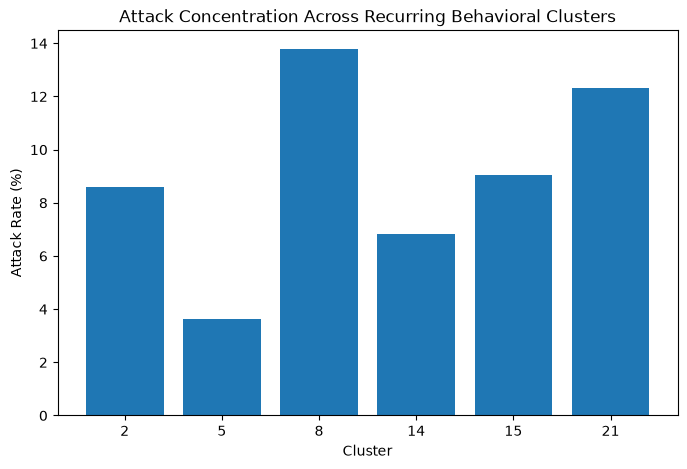

In [122]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    cluster_attack_concentration["improved_cluster"].astype(str),
    cluster_attack_concentration["attack_rate_percent"]
)

plt.xlabel("Cluster")
plt.ylabel("Attack Rate (%)")
plt.title("Attack Concentration Across Recurring Behavioral Clusters")

plt.show()

In [123]:
monthly_cluster_attack_counts = (
    df_processed[
        df_processed["improved_cluster"].isin([2, 5, 8, 14, 15, 21])
    ]
    .groupby(["month", "improved_cluster"])["label"]
    .sum()
    .unstack(fill_value=0)
)

monthly_cluster_attack_counts

improved_cluster,2,5,8,14,15,21
month,,,,,,
2025-10,7,5,0,12,11,3
2025-11,13,6,2,4,9,2
2025-12,11,4,2,8,21,3


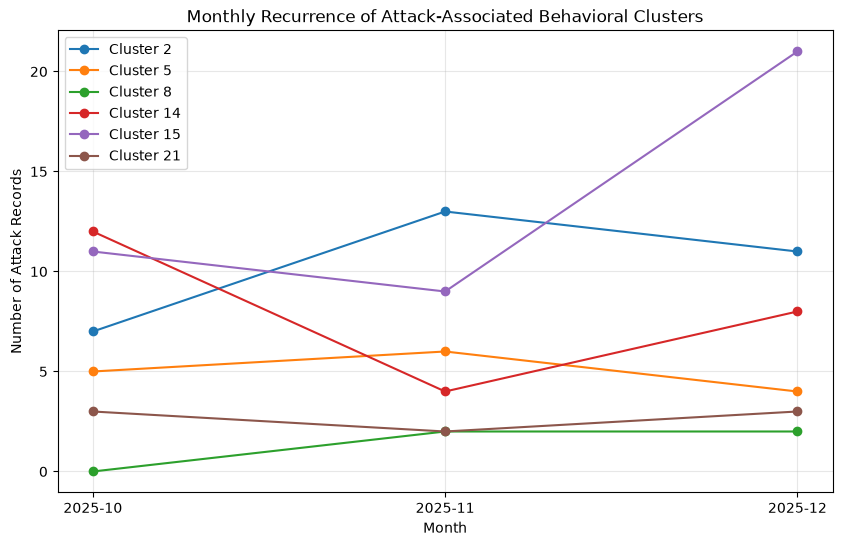

In [124]:
plt.figure(figsize=(10, 6))

for cluster in monthly_cluster_attack_counts.columns:
    plt.plot(
        monthly_cluster_attack_counts.index.astype(str),
        monthly_cluster_attack_counts[cluster],
        marker="o",
        label=f"Cluster {cluster}"
    )

plt.xlabel("Month")
plt.ylabel("Number of Attack Records")
plt.title("Monthly Recurrence of Attack-Associated Behavioral Clusters")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [125]:
attack_profile_matrix = pd.crosstab(
    df_processed["improved_cluster"],
    df_processed["attack_type"]
).loc[[2, 5, 8, 14, 15, 21]]

attack_profile_matrix

attack_type,benign,brute-force,c2,command-injection,credential-stuffing,ddos,exploit-attempt,port-scan,sql-injection,xss
improved_cluster,,,,,,,,,,
2,330,6,0,4,1,0,2,4,7,7
5,400,4,0,1,4,1,1,4,0,0
8,25,3,0,0,0,0,0,1,0,0
14,327,4,0,7,0,0,1,0,8,4
15,412,13,0,4,3,0,1,1,13,6
21,57,1,0,0,0,0,0,0,4,3


In [126]:
attack_only_matrix = attack_profile_matrix.drop(
    columns="benign"
)

attack_composition = (
    attack_only_matrix
    .div(attack_only_matrix.sum(axis=1), axis=0)
    * 100
)

attack_composition.round(2)

attack_type,brute-force,c2,command-injection,credential-stuffing,ddos,exploit-attempt,port-scan,sql-injection,xss
improved_cluster,,,,,,,,,
2,19.35,0.0,12.90,3.23,0.00,6.45,12.90,22.58,22.58
5,26.67,0.0,6.67,26.67,6.67,6.67,26.67,0.00,0.00
8,75.00,0.0,0.00,0.00,0.00,0.00,25.00,0.00,0.00
14,16.67,0.0,29.17,0.00,0.00,4.17,0.00,33.33,16.67
15,31.71,0.0,9.76,7.32,0.00,2.44,2.44,31.71,14.63
21,12.50,0.0,0.00,0.00,0.00,0.00,0.00,50.00,37.50


In [127]:
pattern_names = {
    2: "Mixed Web and Network Attack Pattern",
    5: "Authentication and Scanning Pattern",
    8: "Brute-Force Dominant Pattern",
    14: "Injection-Focused Pattern",
    15: "Mixed Authentication and Web Attack Pattern",
    21: "Web Application Attack Pattern"
}

final_pattern_report["pattern_name"] = (
    final_pattern_report["improved_cluster"]
    .map(pattern_names)
)

final_pattern_report[
    [
        "improved_cluster",
        "pattern_name",
        "recurring_attacks",
        "total_recurring_attacks",
        "attack_types_count",
        "max_months_present",
        "internal_code",
        "url_length",
        "has_sensitive_keyword",
        "is_browser",
        "protocol_TCP",
        "protocol_UDP"
    ]
]

,improved_cluster,pattern_name,recurring_attacks,total_recurring_attacks,attack_types_count,max_months_present,internal_code,url_length,has_sensitive_keyword,is_browser,protocol_TCP,protocol_UDP
0,2,Mixed Web and Network Attack Pattern,"sql-injection, xss, brute-force, command-injec...",28,5,3,0.0,0.000000,0.0,0.0,1.0,0.0
1,5,Authentication and Scanning Pattern,"brute-force, credential-stuffing, port-scan",12,3,3,0.0,41.498795,0.0,1.0,0.0,1.0
2,8,Brute-Force Dominant Pattern,brute-force,3,1,2,1.0,43.689655,1.0,1.0,0.0,1.0
3,14,Injection-Focused Pattern,"sql-injection, command-injection, brute-force,...",23,4,3,0.0,44.717949,1.0,0.0,1.0,0.0
4,15,Mixed Authentication and Web Attack Pattern,"brute-force, sql-injection, xss, credential-st...",39,5,3,0.0,41.944812,0.0,0.0,1.0,0.0
5,21,Web Application Attack Pattern,"sql-injection, xss",7,2,2,1.0,41.830769,0.0,0.0,1.0,0.0


In [128]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

kmeans_results = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans_labels = kmeans.fit_predict(X_improved_scaled)
    
    score = silhouette_score(
        X_improved_scaled,
        kmeans_labels
    )
    
    kmeans_results.append({
        "k": k,
        "silhouette_score": score
    })

kmeans_results_df = pd.DataFrame(kmeans_results)

kmeans_results_df

,k,silhouette_score
0,2,0.265746
1,3,0.267961
2,4,0.158436
3,5,0.174281
4,6,0.178807
5,7,0.208642
6,8,0.194610
7,9,0.204420
8,10,0.196744


In [129]:
kmeans_final = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans_final.fit_predict(
    X_improved_scaled
)

df_processed["kmeans_cluster"] = kmeans_labels

df_processed["kmeans_cluster"].value_counts().sort_index()

kmeans_cluster
0    1910
1    7765
2     325
Name: count, dtype: int64

In [130]:
kmeans_protocol_profile = pd.crosstab(
    df_processed["kmeans_cluster"],
    df_processed["protocol"]
)

kmeans_protocol_profile

protocol,ICMP,TCP,UDP
kmeans_cluster,,,
0,0,0,1910
1,0,7765,0
2,325,0,0


In [131]:
import numpy as np

df_processed["hour_sin"] = np.sin(
    2 * np.pi * df_processed["hour"] / 24
)

df_processed["hour_cos"] = np.cos(
    2 * np.pi * df_processed["hour"] / 24
)

df_processed["day_sin"] = np.sin(
    2 * np.pi * df_processed["day_of_week"] / 7
)

df_processed["day_cos"] = np.cos(
    2 * np.pi * df_processed["day_of_week"] / 7
)

df_processed[
    [
        "hour",
        "hour_sin",
        "hour_cos",
        "day_of_week",
        "day_sin",
        "day_cos"
    ]
].head()

,hour,hour_sin,hour_cos,day_of_week,day_sin,day_cos
0,0,0.0,1.0,2,0.974928,-0.222521
1,0,0.0,1.0,2,0.974928,-0.222521
2,0,0.0,1.0,2,0.974928,-0.222521
3,0,0.0,1.0,2,0.974928,-0.222521
4,0,0.0,1.0,2,0.974928,-0.222521


In [133]:
protocol_encoded = pd.get_dummies(
    df_processed["protocol"],
    prefix="protocol",
    dtype=int
)

In [134]:
X_final = pd.concat(
    [
        df_processed[
            [
                "src_port",
                "dst_port",
                "bytes_sent",
                "bytes_received",
                "bytes_ratio",
                "internal_code",
                "url_length",
                "has_sensitive_keyword",
                "is_browser",
                "hour_sin",
                "hour_cos",
                "day_sin",
                "day_cos"
            ]
        ],
        protocol_encoded
    ],
    axis=1
)

X_final.shape

(10000, 16)

In [135]:
from sklearn.preprocessing import StandardScaler

final_scaler = StandardScaler()

X_final_scaled = final_scaler.fit_transform(X_final)

X_final_scaled.shape

(10000, 16)

In [136]:
from sklearn.cluster import DBSCAN

final_dbscan = DBSCAN(
    eps=1.3,
    min_samples=10
)

final_labels = final_dbscan.fit_predict(X_final_scaled)

df_processed["final_cluster"] = final_labels

df_processed["final_cluster"].value_counts().sort_index()

final_cluster
-1     3206
 0     1423
 1     1532
 2     1863
 3      296
 4      242
 5       32
 6       26
 7      333
 8       32
 9       30
 10      24
 11      57
 12     133
 13      28
 14      32
 15      22
 16      53
 17      49
 18      11
 19       8
 20      20
 21      80
 22      19
 23      18
 24      22
 25      55
 26      25
 27      33
 28       8
 29      21
 30      25
 31      12
 32      35
 33      14
 34      29
 35      14
 36      11
 37      10
 38      15
 39       9
 40      12
 41      13
 42       9
 43       7
 44       5
 45       5
 46       9
 47       2
 48      14
 49      10
 50       7
Name: count, dtype: int64

In [137]:
from sklearn.cluster import DBSCAN

eps_values = [1.3, 1.5, 1.7, 1.9, 2.1]

eps_results = []

for eps in eps_values:
    model = DBSCAN(
        eps=eps,
        min_samples=10
    )
    
    labels = model.fit_predict(X_final_scaled)
    
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_count = (labels == -1).sum()
    
    eps_results.append({
        "eps": eps,
        "clusters": n_clusters,
        "noise_count": noise_count,
        "noise_percent": noise_count / len(labels) * 100
    })

eps_results_df = pd.DataFrame(eps_results)

eps_results_df

,eps,clusters,noise_count,noise_percent
0,1.3,51,3206,32.06
1,1.5,16,1948,19.48
2,1.7,23,1519,15.19
3,1.9,25,1036,10.36
4,2.1,17,779,7.79


In [138]:
from sklearn.metrics import silhouette_score

silhouette_results = []

for eps in eps_values:
    model = DBSCAN(
        eps=eps,
        min_samples=10
    )

    labels = model.fit_predict(X_final_scaled)

    # Ignore noise points (-1) when calculating silhouette score
    non_noise_mask = labels != -1
    non_noise_labels = labels[non_noise_mask]
    non_noise_data = X_final_scaled[non_noise_mask]

    # Silhouette requires at least 2 clusters
    if len(set(non_noise_labels)) >= 2:
        score = silhouette_score(
            non_noise_data,
            non_noise_labels
        )
    else:
        score = np.nan

    silhouette_results.append({
        "eps": eps,
        "clusters": len(set(labels)) - (1 if -1 in labels else 0),
        "noise_percent": (labels == -1).sum() / len(labels) * 100,
        "silhouette_score": score
    })

silhouette_results_df = pd.DataFrame(silhouette_results)

silhouette_results_df

,eps,clusters,noise_percent,silhouette_score
0,1.3,51,32.06,0.074697
1,1.5,16,19.48,0.140933
2,1.7,23,15.19,0.147782
3,1.9,25,10.36,0.156161
4,2.1,17,7.79,0.166041


In [139]:
final_dbscan = DBSCAN(
    eps=2.1,
    min_samples=10
)

final_labels = final_dbscan.fit_predict(X_final_scaled)

df_processed["final_cluster"] = final_labels

df_processed["final_cluster"].value_counts().sort_index()

final_cluster
-1      779
 0     1489
 1      231
 2     3588
 3      834
 4      652
 5      825
 6      241
 7       40
 8       67
 9      372
 10     353
 11      67
 12      45
 13     168
 14      89
 15     127
 16      33
Name: count, dtype: int64

In [140]:
final_cluster_attack_summary = (
    df_processed
    .groupby("final_cluster")
    .agg(
        cluster_size=("label", "size"),
        attack_count=("label", "sum"),
        attack_rate=("label", "mean")
    )
    .reset_index()
)

final_cluster_attack_summary["attack_rate_percent"] = (
    final_cluster_attack_summary["attack_rate"] * 100
)

final_cluster_attack_summary.sort_values(
    "attack_rate_percent",
    ascending=False
)

,final_cluster,cluster_size,attack_count,attack_rate,attack_rate_percent
8,7,40,4,0.100000,10.000000
16,15,127,12,0.094488,9.448819
4,3,834,72,0.086331,8.633094
10,9,372,26,0.069892,6.989247
0,-1,779,46,0.059050,5.905006
2,1,231,11,0.047619,4.761905
15,14,89,4,0.044944,4.494382
12,11,67,3,0.044776,4.477612
13,12,45,2,0.044444,4.444444
14,13,168,6,0.035714,3.571429


In [141]:
final_attack_type_profile = pd.crosstab(
    df_processed["final_cluster"],
    df_processed["attack_type"]
)

final_attack_type_profile

attack_type,benign,brute-force,c2,command-injection,credential-stuffing,ddos,exploit-attempt,port-scan,sql-injection,xss
final_cluster,,,,,,,,,,
-1,733,6,1,0,0,18,1,4,13,3
0,1440,18,2,1,2,2,4,13,4,3
1,220,2,0,1,0,0,0,3,3,2
2,3479,35,4,5,14,3,5,36,4,3
3,762,19,0,8,4,0,3,5,20,13
4,635,4,1,0,3,0,2,6,0,1
5,803,6,0,1,5,1,2,6,1,0
6,236,2,0,0,0,0,2,1,0,0
7,36,3,0,0,0,0,0,1,0,0


In [ ]:
monthly_final_attack_types = pd.crosstab(
    [
        df_processed["month"],
        df_processed["final_cluster"]
    ],
    df_processed["attack_type"]
)

monthly_final_attack_types

attack_type            benign  brute-force  c2  command-injection  \
month   final_cluster                                               
2025-10 -1                269            1   1                  0   
         0                482            5   1                  0   
         1                 69            1   0                  1   
         2               1183            9   1                  4   
         3                248            5   0                  2   
         4                215            1   1                  0   
         5                266            3   0                  0   
         6                 86            0   0                  0   
         7                  8            0   0                  0   
         8                 13            0   0                  0   
         9                117            3   0                  2   
         10               118            3   0                  0   
         11                19            1   1                  0   
         12                16            0   0                  1   
         13                59            1   0                  0   
         14                30            0   0                  1   
         15                34            1   0                  0   
         16                 9            0   0                  0   
2025-11 -1                241            3   0                  0   
         0                470            7   1                  1   
         1                 84            0   0                  0   
         2               1185           15   1                  1   
         3                257            8   0                  2   
         4                222            1   0                  0   
         5                288            1   0                  1   
         6                 72            0   0                  0   
         7                 16            2   0                  0   
         8                 22            1   0                  0   
         9                115            0   0                  2   
         10               110            1   0                  0   
         11                24            0   0                  0   
         12                12            0   0                  0   
         13                48            1   0                  0   
         14                24            0   0                  0   
         15                47            0   0                  0   
         16                13            0   0                  0   
2025-12 -1                223            2   0                  0   
         0                488            6   0                  0   
         1                 67            1   0                  0   
         2               1111           11   2                  0   
         3                257            6   0                  4   
         4                198            2   0                  0   
         5                249            2   0                  0   
         6                 78            2   0                  0   
         7                 12            1   0                  0   
         8                 30            0   0                  0   
         9                114            1   0                  3   
         10               115            0   0                  0   
         11                21            0   0                  0   
         12                15            0   0                  0   
         13                55            0   1                  0   
         14                31            0   0                  0   
         15                34            0   0                  1   
         16                11            0   0                  0   

attack_type            credential-stuffing  ddos  exploit-attempt  port-scan  \
month   final_cluster                                  

In [143]:
# Remove benign records because we are interested only in attack patterns
attack_only_monthly = monthly_final_attack_types.drop(
    columns="benign"
)

# Convert attack counts into presence/absence:
# > 0 means that attack type occurred in that cluster during that month
monthly_presence = attack_only_monthly.gt(0)

# Count the number of different months in which
# each cluster + attack type combination appeared
final_recurrence = (
    monthly_presence
    .groupby(level="final_cluster")
    .sum()
)

final_recurrence

attack_type,brute-force,c2,command-injection,credential-stuffing,ddos,exploit-attempt,port-scan,sql-injection,xss
final_cluster,,,,,,,,,
-1,3,1,0,0,3,1,3,3,2
0,3,2,1,1,1,2,2,3,2
1,2,0,1,0,0,0,3,2,2
2,3,3,2,3,2,2,3,3,2
3,3,0,3,3,0,2,3,3,3
4,3,1,0,1,0,1,3,0,1
5,3,0,1,3,1,1,2,1,0
6,1,0,0,0,0,2,1,0,0
7,2,0,0,0,0,0,1,0,0


In [144]:
# Calculate the total number of attacks for each
# cluster + attack type combination
final_attack_counts = (
    df_processed[
        (df_processed["label"] == 1) &
        (df_processed["final_cluster"] != -1)
    ]
    .groupby(["final_cluster", "attack_type"])
    .size()
    .reset_index(name="total_attacks")
)

# Add the number of months in which each pattern appeared
final_attack_counts["months_present"] = (
    final_attack_counts
    .set_index(["final_cluster", "attack_type"])
    .index.map(
        lambda x: final_recurrence.loc[x[0], x[1]]
    )
)

# Keep patterns that occurred at least 3 times
# and appeared in at least 2 different months
verified_final_patterns = final_attack_counts[
    (final_attack_counts["total_attacks"] >= 3) &
    (final_attack_counts["months_present"] >= 2)
].sort_values(
    ["months_present", "total_attacks"],
    ascending=[False, False]
)

verified_final_patterns

,final_cluster,attack_type,total_attacks,months_present
20,2,port-scan,36,3
14,2,brute-force,35,3
28,3,sql-injection,20,3
23,3,brute-force,19,3
0,0,brute-force,18,3
17,2,credential-stuffing,14,3
29,3,xss,13,3
54,9,sql-injection,9,3
24,3,command-injection,8,3
51,9,command-injection,7,3


In [145]:
threat_pattern_library_final = (
    verified_final_patterns
    .groupby("final_cluster")
    .agg(
        recurring_attack_types=(
            "attack_type",
            lambda x: ", ".join(x)
        ),
        total_recurring_attacks=(
            "total_attacks",
            "sum"
        ),
        recurring_pattern_count=(
            "attack_type",
            "count"
        ),
        max_months_present=(
            "months_present",
            "max"
        )
    )
    .reset_index()
    .sort_values(
        "total_recurring_attacks",
        ascending=False
    )
)

threat_pattern_library_final

,final_cluster,recurring_attack_types,total_recurring_attacks,recurring_pattern_count,max_months_present
2,2,"port-scan, brute-force, credential-stuffing, c...",109,9,3
3,3,"sql-injection, brute-force, xss, command-injec...",72,7,3
0,0,"brute-force, sql-injection, port-scan, exploit...",42,5,3
7,9,"sql-injection, command-injection, brute-force,...",24,4,3
5,5,"brute-force, credential-stuffing, port-scan",17,3,3
4,4,"port-scan, brute-force",10,2,3
9,15,"sql-injection, xss",10,2,3
8,10,"port-scan, brute-force",7,2,3
1,1,"port-scan, sql-injection",6,2,3
6,7,brute-force,3,1,2


In [146]:
pd.set_option("display.max_colwidth", None)

threat_pattern_library_final

,final_cluster,recurring_attack_types,total_recurring_attacks,recurring_pattern_count,max_months_present
2,2,"port-scan, brute-force, credential-stuffing, c2, sql-injection, command-injection, exploit-attempt, ddos, xss",109,9,3
3,3,"sql-injection, brute-force, xss, command-injection, port-scan, credential-stuffing, exploit-attempt",72,7,3
0,0,"brute-force, sql-injection, port-scan, exploit-attempt, xss",42,5,3
7,9,"sql-injection, command-injection, brute-force, xss",24,4,3
5,5,"brute-force, credential-stuffing, port-scan",17,3,3
4,4,"port-scan, brute-force",10,2,3
9,15,"sql-injection, xss",10,2,3
8,10,"port-scan, brute-force",7,2,3
1,1,"port-scan, sql-injection",6,2,3
6,7,brute-force,3,1,2


In [147]:
recurring_clusters = (
    threat_pattern_library_final["final_cluster"]
    .tolist()
)

behavior_features = [
    "src_port",
    "dst_port",
    "bytes_sent",
    "bytes_received",
    "bytes_ratio",
    "internal_code",
    "url_length",
    "has_sensitive_keyword",
    "is_browser",
    "hour",
    "day_of_week"
]

final_behavior_profile = (
    df_processed[
        df_processed["final_cluster"].isin(recurring_clusters)
    ]
    .groupby("final_cluster")[behavior_features]
    .mean()
)

final_behavior_profile

,src_port,dst_port,bytes_sent,bytes_received,bytes_ratio,internal_code,url_length,has_sensitive_keyword,is_browser,hour,day_of_week
final_cluster,,,,,,,,,,,
0,27691.167898,980.615178,73683.462727,157518.458697,0.807971,0.0,44.434520,1.0,1.0,11.399597,3.010745
1,25906.545455,1039.718615,92376.199134,217327.303030,0.655260,0.0,21.558442,0.0,0.0,11.450216,2.948052
2,27342.694537,1076.155797,69296.575530,148122.975474,0.870815,0.0,22.996098,0.0,1.0,11.307971,2.994983
3,26311.401679,1035.478417,75942.269784,156847.152278,0.796177,0.0,23.414868,0.0,0.0,11.264988,2.961631
4,26685.294479,979.019939,68017.039877,144536.495399,0.774290,1.0,22.518405,0.0,1.0,11.268405,3.053681
5,27084.515152,942.707879,71625.305455,177036.120000,0.763072,0.0,21.575758,0.0,1.0,12.029091,3.004848
7,20351.750000,526.050000,40249.800000,92585.450000,0.673253,1.0,44.000000,1.0,1.0,8.875000,2.275000
9,26467.822581,983.833333,82760.099462,170676.661290,0.795619,0.0,44.677419,1.0,0.0,11.284946,3.080645
10,27491.507082,814.079320,60995.181303,120053.008499,0.803345,0.0,44.872521,1.0,1.0,11.130312,3.002833


In [148]:
recurring_port_profile = pd.crosstab(
    df_processed["final_cluster"],
    df_processed["dst_port"],
    normalize="index"
).loc[recurring_clusters]

recurring_port_profile

dst_port,5,16,21,22,25,35,48,53,57,61,...,62624,62925,62954,63140,63217,63530,64323,64819,65416,65491
final_cluster,,,,,,,,,,,,,,,,,,,,,
2,0.0,0.000279,0.094482,0.100056,0.094760,0.000000,0.000279,0.086399,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.000000,0.088729,0.094724,0.092326,0.000000,0.000000,0.110312,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0,0.0,0.000000,0.102754,0.104097,0.089322,0.000000,0.000000,0.097381,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0.0,0.000000,0.086022,0.107527,0.083333,0.000000,0.000000,0.104839,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.000000,0.105455,0.103030,0.099394,0.000000,0.000000,0.094545,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.000000,0.084356,0.081288,0.118098,0.000000,0.000000,0.098160,0.000000,0.001534,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
15,0.0,0.000000,0.086614,0.094488,0.078740,0.000000,0.000000,0.110236,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10,0.0,0.000000,0.104816,0.118980,0.101983,0.002833,0.000000,0.135977,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.000000,0.125541,0.060606,0.108225,0.000000,0.000000,0.060606,0.004329,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [149]:
top_ports_per_cluster = {}

for cluster in recurring_clusters:
    cluster_port_distribution = recurring_port_profile.loc[cluster]
    
    top_ports = (
        cluster_port_distribution
        .sort_values(ascending=False)
        .head(5)
    )
    
    top_ports_per_cluster[cluster] = top_ports

top_ports_per_cluster

{2: dst_port
 80      0.111204
 3306    0.100613
 22      0.100056
 1433    0.098941
 445     0.097826
 Name: 2, dtype: float64,
 3: dst_port
 3389    0.123501
 443     0.112710
 53      0.110312
 445     0.101918
 80      0.098321
 Name: 3, dtype: float64,
 0: dst_port
 443     0.112827
 22      0.104097
 3306    0.104097
 21      0.102754
 1433    0.100067
 Name: 0, dtype: float64,
 9: dst_port
 3306    0.118280
 80      0.115591
 445     0.107527
 22      0.107527
 53      0.104839
 Name: 9, dtype: float64,
 5: dst_port
 80      0.113939
 1433    0.112727
 443     0.105455
 21      0.105455
 22      0.103030
 Name: 5, dtype: float64,
 4: dst_port
 25      0.118098
 443     0.110429
 3306    0.108896
 80      0.107362
 1433    0.099693
 Name: 4, dtype: float64,
 15: dst_port
 443     0.125984
 445     0.118110
 53      0.110236
 3306    0.102362
 1433    0.102362
 Name: 15, dtype: float64,
 10: dst_port
 53     0.135977
 443    0.127479
 22     0.118980
 21     0.104816
 25     0.101

In [150]:
for cluster, ports in top_ports_per_cluster.items():
    print(f"\nCluster {cluster}:")
    
    for port, proportion in ports.items():
        print(f"  Port {port}: {proportion:.2%}")


Cluster 2:
  Port 80: 11.12%
  Port 3306: 10.06%
  Port 22: 10.01%
  Port 1433: 9.89%
  Port 445: 9.78%

Cluster 3:
  Port 3389: 12.35%
  Port 443: 11.27%
  Port 53: 11.03%
  Port 445: 10.19%
  Port 80: 9.83%

Cluster 0:
  Port 443: 11.28%
  Port 22: 10.41%
  Port 3306: 10.41%
  Port 21: 10.28%
  Port 1433: 10.01%

Cluster 9:
  Port 3306: 11.83%
  Port 80: 11.56%
  Port 445: 10.75%
  Port 22: 10.75%
  Port 53: 10.48%

Cluster 5:
  Port 80: 11.39%
  Port 1433: 11.27%
  Port 443: 10.55%
  Port 21: 10.55%
  Port 22: 10.30%

Cluster 4:
  Port 25: 11.81%
  Port 443: 11.04%
  Port 3306: 10.89%
  Port 80: 10.74%
  Port 1433: 9.97%

Cluster 15:
  Port 443: 12.60%
  Port 445: 11.81%
  Port 53: 11.02%
  Port 3306: 10.24%
  Port 1433: 10.24%

Cluster 10:
  Port 53: 13.60%
  Port 443: 12.75%
  Port 22: 11.90%
  Port 21: 10.48%
  Port 25: 10.20%

Cluster 1:
  Port 3389: 13.85%
  Port 1433: 13.42%
  Port 21: 12.55%
  Port 80: 11.26%
  Port 25: 10.82%

Cluster 7:
  Port 22: 20.00%
  Port 443: 15.00%

In [151]:
url_behavior_profile = (
    df_processed[
        df_processed["final_cluster"].isin(recurring_clusters)
    ]
    .groupby("final_cluster")
    .agg(
        avg_url_length=("url_length", "mean"),
        sensitive_url_rate=("has_sensitive_keyword", "mean"),
        browser_rate=("is_browser", "mean"),
        records_with_query_params=("has_query_params", "mean")
    )
)

url_behavior_profile["sensitive_url_rate"] *= 100
url_behavior_profile["browser_rate"] *= 100
url_behavior_profile["records_with_query_params"] *= 100

url_behavior_profile

,avg_url_length,sensitive_url_rate,browser_rate,records_with_query_params
final_cluster,,,,
0,44.434520,100.0,100.0,100.000000
1,21.558442,0.0,0.0,52.380952
2,22.996098,0.0,100.0,55.128205
3,23.414868,0.0,0.0,55.875300
4,22.518405,0.0,100.0,53.527607
5,21.575758,0.0,100.0,52.000000
7,44.000000,100.0,100.0,100.000000
9,44.677419,100.0,0.0,100.000000
10,44.872521,100.0,100.0,100.000000


In [152]:
final_behavior_summary = (
    final_behavior_profile
    .join(
        url_behavior_profile,
        how="left"
    )
    .reset_index()
)

final_behavior_summary

,final_cluster,src_port,dst_port,bytes_sent,bytes_received,bytes_ratio,internal_code,url_length,has_sensitive_keyword,is_browser,hour,day_of_week,avg_url_length,sensitive_url_rate,browser_rate,records_with_query_params
0,0,27691.167898,980.615178,73683.462727,157518.458697,0.807971,0.0,44.434520,1.0,1.0,11.399597,3.010745,44.434520,100.0,100.0,100.000000
1,1,25906.545455,1039.718615,92376.199134,217327.303030,0.655260,0.0,21.558442,0.0,0.0,11.450216,2.948052,21.558442,0.0,0.0,52.380952
2,2,27342.694537,1076.155797,69296.575530,148122.975474,0.870815,0.0,22.996098,0.0,1.0,11.307971,2.994983,22.996098,0.0,100.0,55.128205
3,3,26311.401679,1035.478417,75942.269784,156847.152278,0.796177,0.0,23.414868,0.0,0.0,11.264988,2.961631,23.414868,0.0,0.0,55.875300
4,4,26685.294479,979.019939,68017.039877,144536.495399,0.774290,1.0,22.518405,0.0,1.0,11.268405,3.053681,22.518405,0.0,100.0,53.527607
5,5,27084.515152,942.707879,71625.305455,177036.120000,0.763072,0.0,21.575758,0.0,1.0,12.029091,3.004848,21.575758,0.0,100.0,52.000000
6,7,20351.750000,526.050000,40249.800000,92585.450000,0.673253,1.0,44.000000,1.0,1.0,8.875000,2.275000,44.000000,100.0,100.0,100.000000
7,9,26467.822581,983.833333,82760.099462,170676.661290,0.795619,0.0,44.677419,1.0,0.0,11.284946,3.080645,44.677419,100.0,0.0,100.000000
8,10,27491.507082,814.079320,60995.181303,120053.008499,0.803345,0.0,44.872521,1.0,1.0,11.130312,3.002833,44.872521,100.0,100.0,100.000000
9,15,22337.125984,919.755906,70445.433071,151822.952756,0.702896,1.0,24.677165,0.0,0.0,11.527559,3.464567,24.677165,0.0,0.0,59.055118


In [153]:
final_threat_pattern_report = (
    threat_pattern_library_final
    .merge(
        final_behavior_summary,
        on="final_cluster",
        how="left"
    )
)

final_threat_pattern_report

,final_cluster,recurring_attack_types,total_recurring_attacks,recurring_pattern_count,max_months_present,src_port,dst_port,bytes_sent,bytes_received,bytes_ratio,internal_code,url_length,has_sensitive_keyword,is_browser,hour,day_of_week,avg_url_length,sensitive_url_rate,browser_rate,records_with_query_params
0,2,"port-scan, brute-force, credential-stuffing, c2, sql-injection, command-injection, exploit-attempt, ddos, xss",109,9,3,27342.694537,1076.155797,69296.575530,148122.975474,0.870815,0.0,22.996098,0.0,1.0,11.307971,2.994983,22.996098,0.0,100.0,55.128205
1,3,"sql-injection, brute-force, xss, command-injection, port-scan, credential-stuffing, exploit-attempt",72,7,3,26311.401679,1035.478417,75942.269784,156847.152278,0.796177,0.0,23.414868,0.0,0.0,11.264988,2.961631,23.414868,0.0,0.0,55.875300
2,0,"brute-force, sql-injection, port-scan, exploit-attempt, xss",42,5,3,27691.167898,980.615178,73683.462727,157518.458697,0.807971,0.0,44.434520,1.0,1.0,11.399597,3.010745,44.434520,100.0,100.0,100.000000
3,9,"sql-injection, command-injection, brute-force, xss",24,4,3,26467.822581,983.833333,82760.099462,170676.661290,0.795619,0.0,44.677419,1.0,0.0,11.284946,3.080645,44.677419,100.0,0.0,100.000000
4,5,"brute-force, credential-stuffing, port-scan",17,3,3,27084.515152,942.707879,71625.305455,177036.120000,0.763072,0.0,21.575758,0.0,1.0,12.029091,3.004848,21.575758,0.0,100.0,52.000000
5,4,"port-scan, brute-force",10,2,3,26685.294479,979.019939,68017.039877,144536.495399,0.774290,1.0,22.518405,0.0,1.0,11.268405,3.053681,22.518405,0.0,100.0,53.527607
6,15,"sql-injection, xss",10,2,3,22337.125984,919.755906,70445.433071,151822.952756,0.702896,1.0,24.677165,0.0,0.0,11.527559,3.464567,24.677165,0.0,0.0,59.055118
7,10,"port-scan, brute-force",7,2,3,27491.507082,814.079320,60995.181303,120053.008499,0.803345,0.0,44.872521,1.0,1.0,11.130312,3.002833,44.872521,100.0,100.0,100.000000
8,1,"port-scan, sql-injection",6,2,3,25906.545455,1039.718615,92376.199134,217327.303030,0.655260,0.0,21.558442,0.0,0.0,11.450216,2.948052,21.558442,0.0,0.0,52.380952
9,7,brute-force,3,1,2,20351.750000,526.050000,40249.800000,92585.450000,0.673253,1.0,44.000000,1.0,1.0,8.875000,2.275000,44.000000,100.0,100.0,100.000000


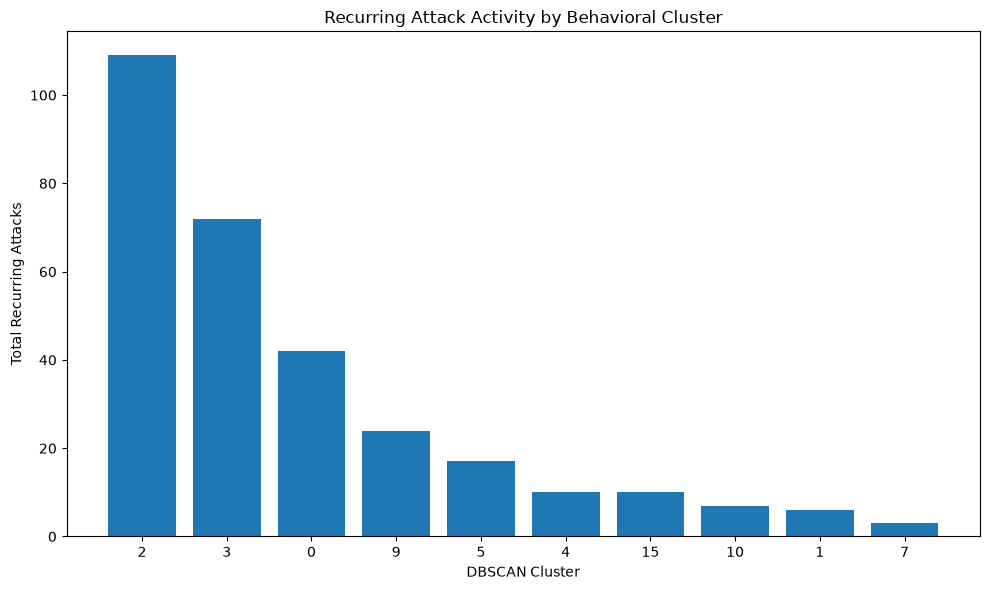

In [154]:
import matplotlib.pyplot as plt

plot_data = threat_pattern_library_final.sort_values(
    "total_recurring_attacks",
    ascending=False
)

plt.figure(figsize=(10, 6))

plt.bar(
    plot_data["final_cluster"].astype(str),
    plot_data["total_recurring_attacks"]
)

plt.xlabel("DBSCAN Cluster")
plt.ylabel("Total Recurring Attacks")
plt.title("Recurring Attack Activity by Behavioral Cluster")

plt.tight_layout()
plt.show()


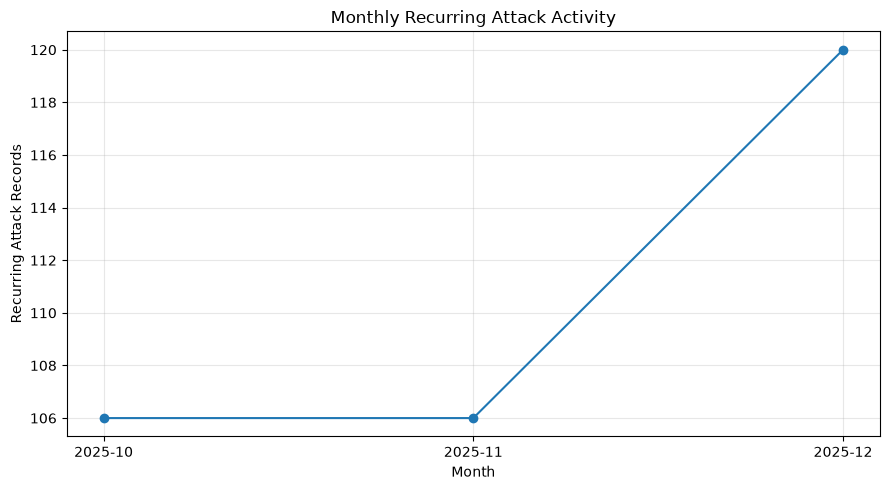

In [155]:
monthly_recurring_attacks = (
    df_processed[
        (df_processed["label"] == 1) &
        (df_processed["final_cluster"].isin(recurring_clusters))
    ]
    .groupby("month")
    .size()
)

plt.figure(figsize=(9, 5))

plt.plot(
    monthly_recurring_attacks.index.astype(str),
    monthly_recurring_attacks.values,
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Recurring Attack Records")
plt.title("Monthly Recurring Attack Activity")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

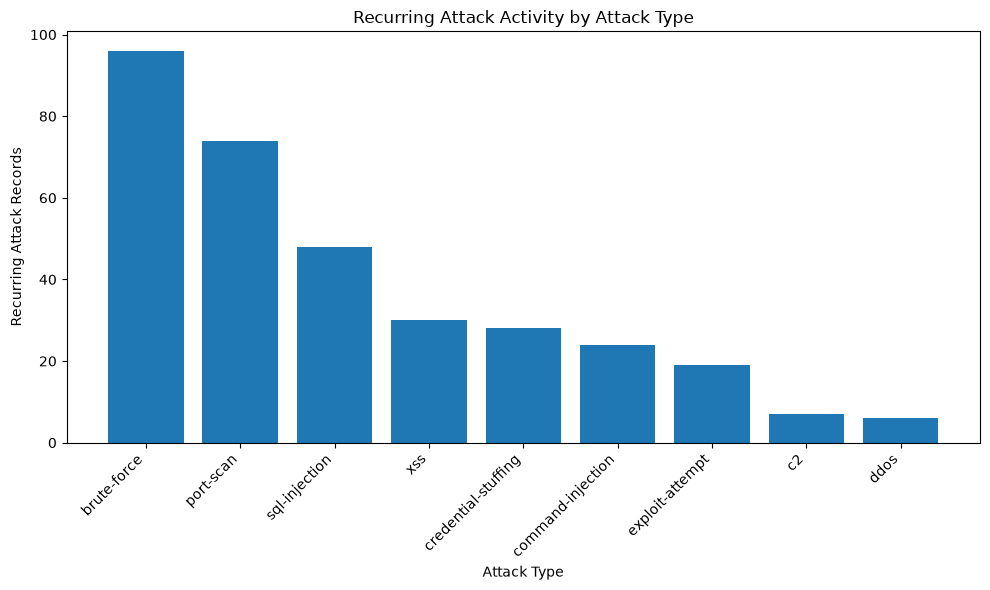

In [156]:
recurring_attack_type_summary = (
    df_processed[
        (df_processed["label"] == 1) &
        (df_processed["final_cluster"].isin(recurring_clusters))
    ]
    .groupby("attack_type")
    .size()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

plt.bar(
    recurring_attack_type_summary.index,
    recurring_attack_type_summary.values
)

plt.xlabel("Attack Type")
plt.ylabel("Recurring Attack Records")
plt.title("Recurring Attack Activity by Attack Type")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

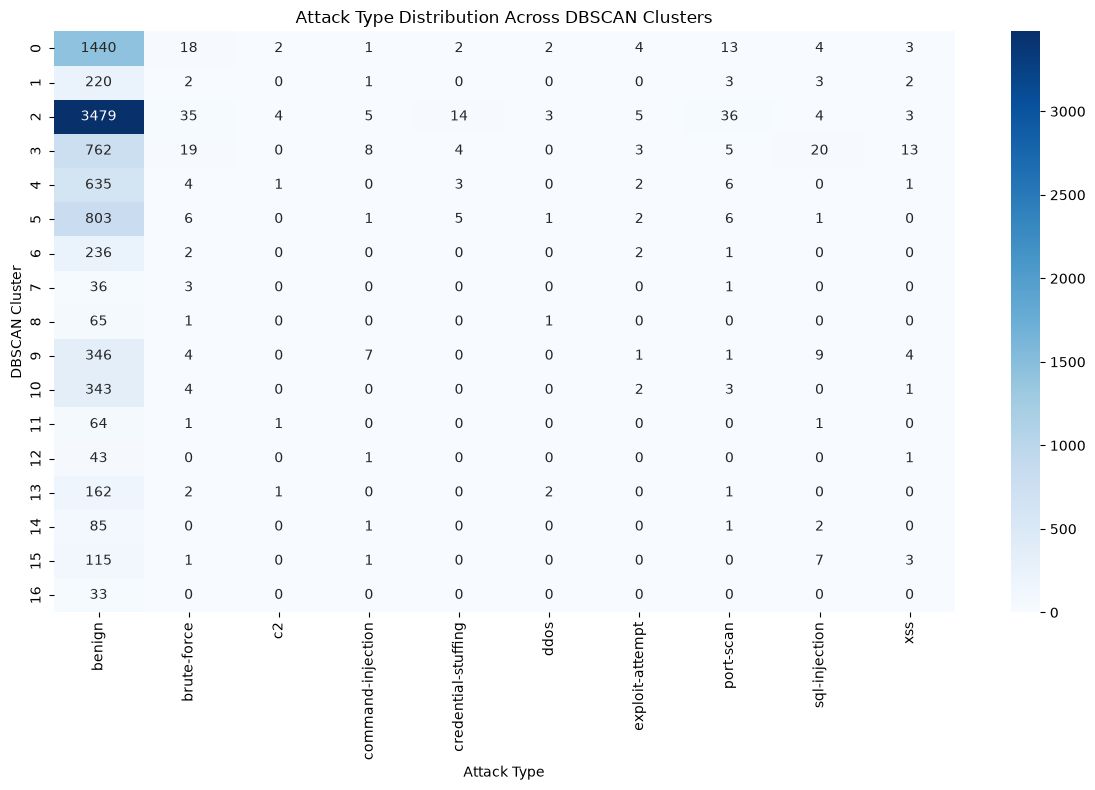

In [158]:
import seaborn as sns

cluster_attack_matrix = pd.crosstab(
    df_processed["final_cluster"],
    df_processed["attack_type"]
)

cluster_attack_matrix = cluster_attack_matrix.drop(
    index=-1,
    errors="ignore"
)

plt.figure(figsize=(12, 8))

sns.heatmap(
    cluster_attack_matrix,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Attack Type")
plt.ylabel("DBSCAN Cluster")
plt.title("Attack Type Distribution Across DBSCAN Clusters")

plt.tight_layout()
plt.show()

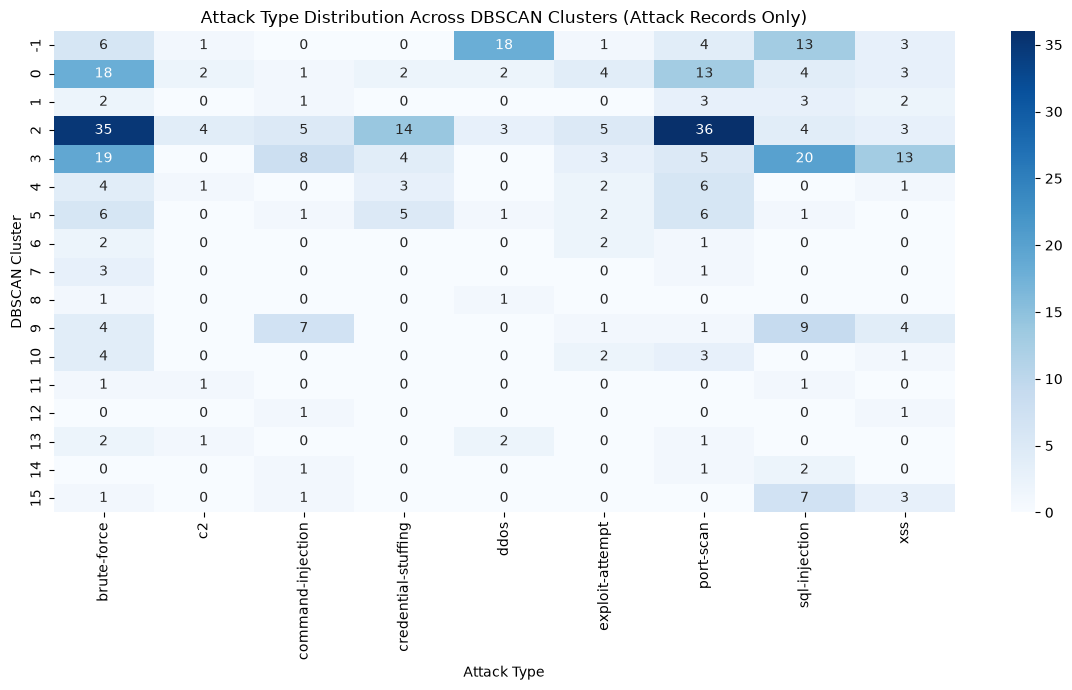

In [159]:
attack_cluster_matrix = pd.crosstab(
    df_processed.loc[df_processed["label"] == 1, "final_cluster"],
    df_processed.loc[df_processed["label"] == 1, "attack_type"]
)

plt.figure(figsize=(12, 7))

sns.heatmap(
    attack_cluster_matrix,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Attack Type")
plt.ylabel("DBSCAN Cluster")
plt.title("Attack Type Distribution Across DBSCAN Clusters (Attack Records Only)")

plt.tight_layout()
plt.show()

In [160]:
final_threat_pattern_library = threat_pattern_library_final.copy()

final_threat_pattern_library = final_threat_pattern_library.rename(
    columns={
        "final_cluster": "Cluster",
        "recurring_attack_types": "Recurring Attack Types",
        "total_recurring_attacks": "Total Recurring Attacks",
        "recurring_pattern_count": "Number of Recurring Attack Types",
        "max_months_present": "Months Present"
    }
)

final_threat_pattern_library

,Cluster,Recurring Attack Types,Total Recurring Attacks,Number of Recurring Attack Types,Months Present
2,2,"port-scan, brute-force, credential-stuffing, c2, sql-injection, command-injection, exploit-attempt, ddos, xss",109,9,3
3,3,"sql-injection, brute-force, xss, command-injection, port-scan, credential-stuffing, exploit-attempt",72,7,3
0,0,"brute-force, sql-injection, port-scan, exploit-attempt, xss",42,5,3
7,9,"sql-injection, command-injection, brute-force, xss",24,4,3
5,5,"brute-force, credential-stuffing, port-scan",17,3,3
4,4,"port-scan, brute-force",10,2,3
9,15,"sql-injection, xss",10,2,3
8,10,"port-scan, brute-force",7,2,3
1,1,"port-scan, sql-injection",6,2,3
6,7,brute-force,3,1,2


In [161]:
final_threat_pattern_library = final_threat_pattern_library.reset_index(drop=True)

final_threat_pattern_library

,Cluster,Recurring Attack Types,Total Recurring Attacks,Number of Recurring Attack Types,Months Present
0,2,"port-scan, brute-force, credential-stuffing, c2, sql-injection, command-injection, exploit-attempt, ddos, xss",109,9,3
1,3,"sql-injection, brute-force, xss, command-injection, port-scan, credential-stuffing, exploit-attempt",72,7,3
2,0,"brute-force, sql-injection, port-scan, exploit-attempt, xss",42,5,3
3,9,"sql-injection, command-injection, brute-force, xss",24,4,3
4,5,"brute-force, credential-stuffing, port-scan",17,3,3
5,4,"port-scan, brute-force",10,2,3
6,15,"sql-injection, xss",10,2,3
7,10,"port-scan, brute-force",7,2,3
8,1,"port-scan, sql-injection",6,2,3
9,7,brute-force,3,1,2


In [162]:
import os

os.makedirs("../outputs/reports", exist_ok=True)

final_threat_pattern_library.to_csv(
    "../outputs/reports/threat_pattern_library.csv",
    index=False
)

print("Threat Pattern Library saved successfully.")

Threat Pattern Library saved successfully.


In [163]:
import os

os.makedirs("../data/processed", exist_ok=True)

df_processed.to_csv(
    "../data/processed/cybersecurity_processed.csv",
    index=False
)

print("Processed dataset saved successfully.")
print("Shape:", df_processed.shape)

Processed dataset saved successfully.
Shape: (10000, 36)


In [164]:
final_threat_pattern_report.to_csv(
    "../outputs/reports/detailed_threat_pattern_report.csv",
    index=False
)

print("Detailed Threat Pattern Report saved successfully.")
print("Rows:", len(final_threat_pattern_report))
print("Columns:", len(final_threat_pattern_report.columns))

Detailed Threat Pattern Report saved successfully.
Rows: 10
Columns: 20


In [165]:
project_summary = {
    "Total Security Logs": len(df_processed),
    "Total Attack Records": int(df_processed["label"].sum()),
    "Total Benign Records": int((df_processed["label"] == 0).sum()),
    "Total DBSCAN Clusters": int(
        df_processed.loc[df_processed["final_cluster"] != -1, "final_cluster"].nunique()
    ),
    "Noise Records": int(
        (df_processed["final_cluster"] == -1).sum()
    ),
    "Recurring Clusters": len(recurring_clusters),
    "Recurring Attack Types": int(
        df_processed[
            (df_processed["label"] == 1) &
            (df_processed["final_cluster"].isin(recurring_clusters))
        ]["attack_type"].nunique()
    )
}

project_summary

{'Total Security Logs': 10000,
 'Total Attack Records': 400,
 'Total Benign Records': 9600,
 'Total DBSCAN Clusters': 17,
 'Noise Records': 779,
 'Recurring Clusters': 10,
 'Recurring Attack Types': 9}

In [166]:
project_summary_df = pd.DataFrame(
    list(project_summary.items()),
    columns=["Metric", "Value"]
)

project_summary_df.to_csv(
    "../outputs/reports/project_summary.csv",
    index=False
)

print("Project summary saved successfully.")

Project summary saved successfully.


In [167]:
import sys
sys.path.append("../src")

from preprocessing import load_data, engineer_features
from clustering import (
    prepare_clustering_features,
    scale_features,
    apply_dbscan
)

In [168]:
df_test = load_data("../data/raw/cybersecurity.csv")

print("Dataset loaded successfully.")
print("Shape:", df_test.shape)

Dataset loaded successfully.
Shape: (10000, 13)


In [169]:
df_test_processed = engineer_features(df_test)

print("Feature engineering completed successfully.")
print("Shape:", df_test_processed.shape)

Feature engineering completed successfully.
Shape: (10000, 30)


In [170]:
X_test = prepare_clustering_features(df_test_processed)

print("Clustering features prepared successfully.")
print("Shape:", X_test.shape)
print("\nFeatures:")
print(X_test.columns.tolist())

Clustering features prepared successfully.
Shape: (10000, 16)

Features:
['src_port', 'dst_port', 'bytes_sent', 'bytes_received', 'bytes_ratio', 'internal_code', 'url_length', 'has_sensitive_keyword', 'is_browser', 'hour_sin', 'hour_cos', 'day_sin', 'day_cos', 'protocol_ICMP', 'protocol_TCP', 'protocol_UDP']


In [171]:
X_test_scaled, scaler_test = scale_features(X_test)

print("Feature scaling completed successfully.")
print("Shape:", X_test_scaled.shape)
print("Mean of first feature:", X_test_scaled[:, 0].mean())
print("Standard deviation of first feature:", X_test_scaled[:, 0].std())

Feature scaling completed successfully.
Shape: (10000, 16)
Mean of first feature: 5.3645976549887566e-17
Standard deviation of first feature: 1.0


In [172]:
cluster_labels_test, dbscan_test = apply_dbscan(
    X_test_scaled,
    eps=2.1,
    min_samples=10
)

print("DBSCAN clustering completed successfully.")
print("Number of clusters:", len(set(cluster_labels_test)) - (1 if -1 in cluster_labels_test else 0))
print("Noise records:", list(cluster_labels_test).count(-1))

DBSCAN clustering completed successfully.
Number of clusters: 17
Noise records: 779


In [173]:
df_test_processed["final_cluster"] = cluster_labels_test

print("Cluster labels added successfully.")
print(df_test_processed["final_cluster"].value_counts().sort_index())

Cluster labels added successfully.
final_cluster
-1      779
 0     1489
 1      231
 2     3588
 3      834
 4      652
 5      825
 6      241
 7       40
 8       67
 9      372
 10     353
 11      67
 12      45
 13     168
 14      89
 15     127
 16      33
Name: count, dtype: int64


In [174]:
from analysis import (
    add_month_column,
    create_monthly_attack_table,
    calculate_recurrence,
    identify_recurring_patterns,
    create_threat_pattern_library,
    create_behavior_profile,
    create_url_behavior_profile,
    create_behavior_summary,
    create_detailed_threat_report
)

print("Analysis module imported successfully.")

Analysis module imported successfully.


In [175]:
df_analysis_test = add_month_column(df_test_processed)

print("Month column added successfully.")
print(df_analysis_test[["timestamp", "month"]].head())

Month column added successfully.
            timestamp    month
0 2025-10-01 00:12:54  2025-10
1 2025-10-01 00:23:43  2025-10
2 2025-10-01 00:25:46  2025-10
3 2025-10-01 00:27:21  2025-10
4 2025-10-01 00:40:09  2025-10


In [176]:
monthly_attack_test = create_monthly_attack_table(
    df_analysis_test
)

print("Monthly attack table created successfully.")
monthly_attack_test.head(10)

Monthly attack table created successfully.


attack_type            benign  brute-force  c2  command-injection  \
month   final_cluster                                               
2025-10 -1                269            1   1                  0   
         0                482            5   1                  0   
         1                 69            1   0                  1   
         2               1183            9   1                  4   
         3                248            5   0                  2   
         4                215            1   1                  0   
         5                266            3   0                  0   
         6                 86            0   0                  0   
         7                  8            0   0                  0   
         8                 13            0   0                  0   

attack_type            credential-stuffing  ddos  exploit-attempt  port-scan  \
month   final_cluster                                                          
2025-10 -1                               0     7                0          2   
         0                               2     0                0          0   
         1                               0     0                0          1   
         2                               3     0                1         16   
         3                               1     0                0          1   
         4                               0     0                0          2   
         5                               2     0                0          2   
         6                               0     0                1          0   
         7                               0     0                0          0   
         8                               0     0                0          0   

attack_type            sql-injection  xss  
month   final_cluster                      
2025-10 -1                         5    1  
         0                         2    0  
         1                         2    1  
         2                         1    2  
         3                         6    3  
         4                         0    0  
         5                         0    0  
         6                         0    0  
         7                         0    0  
         8                         0    0

In [177]:
recurrence_test = calculate_recurrence(
    monthly_attack_test
)

print("Monthly recurrence calculated successfully.")
recurrence_test

Monthly recurrence calculated successfully.


attack_type,brute-force,c2,command-injection,credential-stuffing,ddos,exploit-attempt,port-scan,sql-injection,xss
final_cluster,,,,,,,,,
-1,3,1,0,0,3,1,3,3,2
0,3,2,1,1,1,2,2,3,2
1,2,0,1,0,0,0,3,2,2
2,3,3,2,3,2,2,3,3,2
3,3,0,3,3,0,2,3,3,3
4,3,1,0,1,0,1,3,0,1
5,3,0,1,3,1,1,2,1,0
6,1,0,0,0,0,2,1,0,0
7,2,0,0,0,0,0,1,0,0


In [179]:
recurring_patterns_test = identify_recurring_patterns(
    df_analysis_test,
    minimum_attacks=3,
    minimum_months=2
)

print("Recurring patterns identified successfully.")
print("Number of recurring patterns:", len(recurring_patterns_test))

recurring_patterns_test

Recurring patterns identified successfully.
Number of recurring patterns: 37


,final_cluster,attack_type,total_attacks,months_present
0,0,brute-force,18,3
5,0,exploit-attempt,4,2
6,0,port-scan,13,2
7,0,sql-injection,4,3
8,0,xss,3,2
11,1,port-scan,3,3
12,1,sql-injection,3,2
14,2,brute-force,35,3
15,2,c2,4,3
16,2,command-injection,5,2


In [180]:
threat_library_test = create_threat_pattern_library(
    recurring_patterns_test
)

print("Threat Pattern Library created successfully.")
print("Number of recurring clusters:", len(threat_library_test))

threat_library_test

Threat Pattern Library created successfully.
Number of recurring clusters: 10


,final_cluster,recurring_attack_types,total_recurring_attacks,recurring_pattern_count,max_months_present
2,2,"brute-force, c2, command-injection, credential-stuffing, ddos, exploit-attempt, port-scan, sql-injection, xss",109,9,3
3,3,"brute-force, command-injection, credential-stuffing, exploit-attempt, port-scan, sql-injection, xss",72,7,3
0,0,"brute-force, exploit-attempt, port-scan, sql-injection, xss",42,5,3
7,9,"brute-force, command-injection, sql-injection, xss",24,4,3
5,5,"brute-force, credential-stuffing, port-scan",17,3,3
4,4,"brute-force, port-scan",10,2,3
9,15,"sql-injection, xss",10,2,3
8,10,"brute-force, port-scan",7,2,3
1,1,"port-scan, sql-injection",6,2,3
6,7,brute-force,3,1,2


In [181]:
recurring_clusters_test = threat_library_test["final_cluster"].tolist()

behavior_profile_test = create_behavior_profile(
    df_analysis_test,
    recurring_clusters_test
)

print("Behavior profile created successfully.")
behavior_profile_test

Behavior profile created successfully.


,src_port,dst_port,bytes_sent,bytes_received,bytes_ratio,internal_code,url_length,has_sensitive_keyword,is_browser,hour,day_of_week
final_cluster,,,,,,,,,,,
0,27691.167898,980.615178,73683.462727,157518.458697,0.807971,0.0,44.434520,1.0,1.0,11.399597,3.010745
1,25906.545455,1039.718615,92376.199134,217327.303030,0.655260,0.0,21.558442,0.0,0.0,11.450216,2.948052
2,27342.694537,1076.155797,69296.575530,148122.975474,0.870815,0.0,22.996098,0.0,1.0,11.307971,2.994983
3,26311.401679,1035.478417,75942.269784,156847.152278,0.796177,0.0,23.414868,0.0,0.0,11.264988,2.961631
4,26685.294479,979.019939,68017.039877,144536.495399,0.774290,1.0,22.518405,0.0,1.0,11.268405,3.053681
5,27084.515152,942.707879,71625.305455,177036.120000,0.763072,0.0,21.575758,0.0,1.0,12.029091,3.004848
7,20351.750000,526.050000,40249.800000,92585.450000,0.673253,1.0,44.000000,1.0,1.0,8.875000,2.275000
9,26467.822581,983.833333,82760.099462,170676.661290,0.795619,0.0,44.677419,1.0,0.0,11.284946,3.080645
10,27491.507082,814.079320,60995.181303,120053.008499,0.803345,0.0,44.872521,1.0,1.0,11.130312,3.002833


In [182]:
url_behavior_profile_test = create_url_behavior_profile(
    df_analysis_test,
    recurring_clusters_test
)

print("URL behavior profile created successfully.")
url_behavior_profile_test

URL behavior profile created successfully.


,avg_url_length,sensitive_url_rate,browser_rate,records_with_query_params
final_cluster,,,,
0,44.434520,1.0,1.0,1.000000
1,21.558442,0.0,0.0,0.523810
2,22.996098,0.0,1.0,0.551282
3,23.414868,0.0,0.0,0.558753
4,22.518405,0.0,1.0,0.535276
5,21.575758,0.0,1.0,0.520000
7,44.000000,1.0,1.0,1.000000
9,44.677419,1.0,0.0,1.000000
10,44.872521,1.0,1.0,1.000000


In [183]:
behavior_summary_test = create_behavior_summary(
    behavior_profile_test,
    url_behavior_profile_test
)

print("Behavior summary created successfully.")
print("Shape:", behavior_summary_test.shape)

behavior_summary_test

Behavior summary created successfully.
Shape: (10, 16)


,final_cluster,src_port,dst_port,bytes_sent,bytes_received,bytes_ratio,internal_code,url_length,has_sensitive_keyword,is_browser,hour,day_of_week,avg_url_length,sensitive_url_rate,browser_rate,records_with_query_params
0,0,27691.167898,980.615178,73683.462727,157518.458697,0.807971,0.0,44.434520,1.0,1.0,11.399597,3.010745,44.434520,1.0,1.0,1.000000
1,1,25906.545455,1039.718615,92376.199134,217327.303030,0.655260,0.0,21.558442,0.0,0.0,11.450216,2.948052,21.558442,0.0,0.0,0.523810
2,2,27342.694537,1076.155797,69296.575530,148122.975474,0.870815,0.0,22.996098,0.0,1.0,11.307971,2.994983,22.996098,0.0,1.0,0.551282
3,3,26311.401679,1035.478417,75942.269784,156847.152278,0.796177,0.0,23.414868,0.0,0.0,11.264988,2.961631,23.414868,0.0,0.0,0.558753
4,4,26685.294479,979.019939,68017.039877,144536.495399,0.774290,1.0,22.518405,0.0,1.0,11.268405,3.053681,22.518405,0.0,1.0,0.535276
5,5,27084.515152,942.707879,71625.305455,177036.120000,0.763072,0.0,21.575758,0.0,1.0,12.029091,3.004848,21.575758,0.0,1.0,0.520000
6,7,20351.750000,526.050000,40249.800000,92585.450000,0.673253,1.0,44.000000,1.0,1.0,8.875000,2.275000,44.000000,1.0,1.0,1.000000
7,9,26467.822581,983.833333,82760.099462,170676.661290,0.795619,0.0,44.677419,1.0,0.0,11.284946,3.080645,44.677419,1.0,0.0,1.000000
8,10,27491.507082,814.079320,60995.181303,120053.008499,0.803345,0.0,44.872521,1.0,1.0,11.130312,3.002833,44.872521,1.0,1.0,1.000000
9,15,22337.125984,919.755906,70445.433071,151822.952756,0.702896,1.0,24.677165,0.0,0.0,11.527559,3.464567,24.677165,0.0,0.0,0.590551


In [184]:
detailed_report_test = create_detailed_threat_report(
    threat_library_test,
    behavior_summary_test
)

print("Detailed Threat Pattern Report created successfully.")
print("Shape:", detailed_report_test.shape)

detailed_report_test

Detailed Threat Pattern Report created successfully.
Shape: (10, 20)


,final_cluster,recurring_attack_types,total_recurring_attacks,recurring_pattern_count,max_months_present,src_port,dst_port,bytes_sent,bytes_received,bytes_ratio,internal_code,url_length,has_sensitive_keyword,is_browser,hour,day_of_week,avg_url_length,sensitive_url_rate,browser_rate,records_with_query_params
0,2,"brute-force, c2, command-injection, credential-stuffing, ddos, exploit-attempt, port-scan, sql-injection, xss",109,9,3,27342.694537,1076.155797,69296.575530,148122.975474,0.870815,0.0,22.996098,0.0,1.0,11.307971,2.994983,22.996098,0.0,1.0,0.551282
1,3,"brute-force, command-injection, credential-stuffing, exploit-attempt, port-scan, sql-injection, xss",72,7,3,26311.401679,1035.478417,75942.269784,156847.152278,0.796177,0.0,23.414868,0.0,0.0,11.264988,2.961631,23.414868,0.0,0.0,0.558753
2,0,"brute-force, exploit-attempt, port-scan, sql-injection, xss",42,5,3,27691.167898,980.615178,73683.462727,157518.458697,0.807971,0.0,44.434520,1.0,1.0,11.399597,3.010745,44.434520,1.0,1.0,1.000000
3,9,"brute-force, command-injection, sql-injection, xss",24,4,3,26467.822581,983.833333,82760.099462,170676.661290,0.795619,0.0,44.677419,1.0,0.0,11.284946,3.080645,44.677419,1.0,0.0,1.000000
4,5,"brute-force, credential-stuffing, port-scan",17,3,3,27084.515152,942.707879,71625.305455,177036.120000,0.763072,0.0,21.575758,0.0,1.0,12.029091,3.004848,21.575758,0.0,1.0,0.520000
5,4,"brute-force, port-scan",10,2,3,26685.294479,979.019939,68017.039877,144536.495399,0.774290,1.0,22.518405,0.0,1.0,11.268405,3.053681,22.518405,0.0,1.0,0.535276
6,15,"sql-injection, xss",10,2,3,22337.125984,919.755906,70445.433071,151822.952756,0.702896,1.0,24.677165,0.0,0.0,11.527559,3.464567,24.677165,0.0,0.0,0.590551
7,10,"brute-force, port-scan",7,2,3,27491.507082,814.079320,60995.181303,120053.008499,0.803345,0.0,44.872521,1.0,1.0,11.130312,3.002833,44.872521,1.0,1.0,1.000000
8,1,"port-scan, sql-injection",6,2,3,25906.545455,1039.718615,92376.199134,217327.303030,0.655260,0.0,21.558442,0.0,0.0,11.450216,2.948052,21.558442,0.0,0.0,0.523810
9,7,brute-force,3,1,2,20351.750000,526.050000,40249.800000,92585.450000,0.673253,1.0,44.000000,1.0,1.0,8.875000,2.275000,44.000000,1.0,1.0,1.000000
